In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display

import sys
import os
sys.path.append("../src")
from utils import (
    set_aesthetics,
    load_data,
    assess_quality,
    plot_class_distribution,
    plot_correlation_heatmap
)

# ── Aesthetics ──
FRAUD_PAL = {0: "#4C72B0", 1: "#DD4444", "0": "#4C72B0", "1": "#DD4444"}   # blue = normal, red = fraud
SEED = 42
set_aesthetics(palette_style="muted", font_scale=1.1)

Libraries loaded & global aesthetics set ✓


### Data Loading

In [ ]:
Credit_df_raw = load_data('../data/raw/creditcard.csv')
Credit_df_raw.head(3)



Loading data from: ../data/raw/creditcard.csv
Shape  : 284,807 rows × 31 columns
Memory : 70.6 MB


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,...,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,...,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,...,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0


In [ ]:
Fraud_df_raw = load_data('../data/raw/Fraud_Data.csv')
Fraud_df_raw.head(3)


Loading data from: ../data/raw/Fraud_Data.csv
Shape  : 151,112 rows × 11 columns
Memory : 59.7 MB


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,732758368.7997,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,350311387.8659,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2621473820.1109,1


In [ ]:
IpAddress_to_Country_df_raw = load_data('../data/raw/IpAddress_to_Country.csv')
IpAddress_to_Country_df_raw.head(3)

Loading data from: ../data/raw/IpAddress_to_Country.csv
Shape  : 138,846 rows × 3 columns
Memory : 10.5 MB


,lower_bound_ip_address,upper_bound_ip_address,country
0,16777216.0000,16777471,Australia
1,16777472.0000,16777727,China
2,16777728.0000,16778239,China


Data Cleaning

In [ ]:
Credit_df_raw.dtypes.to_frame("dtype")

,dtype
Time,float64
V1,float64
V2,float64
V3,float64
V4,float64
V5,float64
V6,float64
V7,float64
V8,float64
V9,float64


In [ ]:
Fraud_df_raw.dtypes.to_frame("dtype")


,dtype
user_id,int64
signup_time,str
purchase_time,str
purchase_value,int64
device_id,str
source,str
browser,str
sex,str
age,int64
ip_address,float64


In [ ]:
IpAddress_to_Country_df_raw.dtypes.to_frame("dtype")

,dtype
lower_bound_ip_address,float64
upper_bound_ip_address,int64
country,str


In [ ]:
print("Statistical summary (core numeric columns)")
display(Credit_df_raw[["Time","Amount","Class"]].describe())



Statistical summary (core numeric columns)


,Time,Amount,Class
count,284807.0000,284807.0000,284807.0000
mean,94813.8596,88.3496,0.0017
std,47488.1460,250.1201,0.0415
min,0.0000,0.0000,0.0000
25%,54201.5000,5.6000,0.0000
50%,84692.0000,22.0000,0.0000
75%,139320.5000,77.1650,0.0000
max,172792.0000,25691.1600,1.0000


In [ ]:
print("Statistical summary (core numeric columns)")
display(Fraud_df_raw[["purchase_value","ip_address","class"]].describe())


Statistical summary (core numeric columns)


,purchase_value,ip_address,class
count,151112.0000,151112.0000,151112.0000
mean,36.9354,2152145330.9588,0.0936
std,18.3228,1248497030.1004,0.2913
min,9.0000,52093.4969,0.0000
25%,22.0000,1085933882.5316,0.0000
50%,35.0000,2154770162.4066,0.0000
75%,49.0000,3243257679.7225,0.0000
max,154.0000,4294850499.6788,1.0000


In [ ]:
print("Statistical summary (core numeric columns)")
display(IpAddress_to_Country_df_raw[["upper_bound_ip_address","lower_bound_ip_address"]].describe())

Statistical summary (core numeric columns)


,upper_bound_ip_address,lower_bound_ip_address
count,138846.0000,138846.0000
mean,2724557062.2184,2724531562.5160
std,897497915.4601,897521519.7116
min,16777471.0000,16777216.0000
25%,1920008191.0000,1919930368.0000
50%,3230887551.0000,3230887296.0000
75%,3350465919.0000,3350465280.0000
max,3758096383.0000,3758096128.0000


In [ ]:
quality_report, n_dup = assess_quality(Credit_df_raw)



No missing values detected.

Duplicate rows : 1,081


In [ ]:
quality_report, n_dup = assess_quality(Fraud_df_raw)


No missing values detected.

Duplicate rows : 0


In [ ]:

quality_report, n_dup = assess_quality(IpAddress_to_Country_df_raw)

No missing values detected.

Duplicate rows : 0


In [ ]:
credit_df = Credit_df_raw.copy()
# Step 1-2: drop rows missing Class or Amount
before = len(credit_df)
credit_df = credit_df.dropna(subset=["Class", "Amount"])
print(f"Dropped {before - len(credit_df):,} rows missing Class / Amount")
# Step 3: remove duplicates
before = len(credit_df)
credit_df = credit_df.drop_duplicates()
print(f"Removed {before - len(credit_df):,} duplicate rows")
# Step 4: cast dtypes
credit_df["Class"] = credit_df["Class"].astype(int)
credit_df["Time"]  = credit_df["Time"].astype(int)
print(f"\nCleaned dataset : {len(credit_df):,} rows × {credit_df.shape[1]} columns")
credit_df.dtypes.to_frame("dtype").T


Dropped 0 rows missing Class / Amount
Removed 1,081 duplicate rows

Cleaned dataset : 283,726 rows × 31 columns


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
dtype,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,...,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64


Exploratory Data Analysis

In [ ]:
amt_stats = credit_df.groupby("Class")["Amount"].describe().T
amt_stats.columns = ["Normal", "Fraud"]
display(amt_stats.style.format("{:.4f}"))

,Normal,Fraud
count,283253.0000,473.0000
mean,88.4136,123.8719
std,250.3790,260.2110
min,0.0000,0.0000
25%,5.6700,1.0000
50%,22.0000,9.8200
75%,77.4600,105.8900
max,25691.1600,2125.8700


,count,percent_%
Normal (0),283253,99.8333
Fraud (1),473,0.1667



Imbalance ratio (Normal : Fraud) = 599 : 1
Saved class distribution plot to: ../notebooks/cc_class_distribution.png


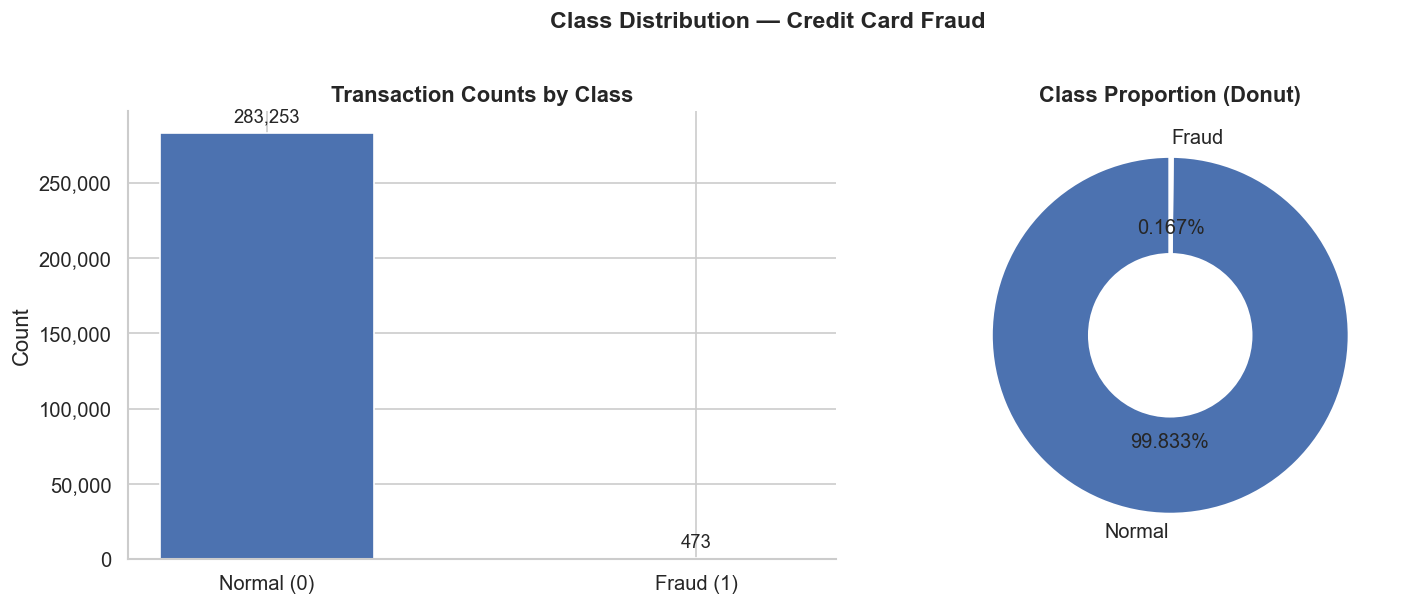

In [ ]:
plot_class_distribution(credit_df, "Class", "Class Distribution — Credit Card Fraud", palette=FRAUD_PAL, save_path="../notebooks/cc_class_distribution.png")

### Class Distribution — Credit Card Fraud
This plot clearly visualizes the severe class imbalance in the credit card fraud dataset.

*   **Normal (Class 0)**: Represents the vast majority of transactions.
*   **Fraud (Class 1)**: Constitutes a tiny fraction of the total transactions.
*   **Imbalance Ratio**: The output `Imbalance ratio (Normal : Fraud) = 599 : 1` indicates that for every 599 normal transactions, there is only 1 fraudulent transaction. This extreme imbalance is typical in fraud detection datasets and poses a significant challenge for machine learning models, as models can achieve high accuracy by simply predicting the majority class, while failing to detect the rare, but crucial, fraudulent cases. This problem will likely need to be addressed using techniques like oversampling (e.g., SMOTE) or undersampling.

In [ ]:
The chart and the accompanying text highlight a critical issue in the fraud detection dataset: **class imbalance**.

### Original Dataset:
*   **Extreme Imbalance**: The original dataset shows an extreme imbalance with a **28:1 ratio** between the 'Repaid' (non-fraudulent) and 'Default' (fraudulent) classes. This means for every 28 non-fraudulent transactions, there is only 1 fraudulent transaction.
*   **Impact**: As the text states, the 'Default' bar is barely visible, indicating that fraudulent cases are a tiny minority. If a model were trained on this data without addressing the imbalance, it would likely become biased towards the majority class (non-fraudulent transactions). It would achieve high overall accuracy by simply predicting most transactions as non-fraudulent, but it would be very poor at identifying actual fraud (which is the goal).

### SMOTE (Synthetic Minority Over-sampling Technique):
*   **Purpose**: SMOTE is a technique used to address class imbalance by generating synthetic samples for the minority class. Instead of simply duplicating existing minority class samples, SMOTE creates new, synthetic examples that are similar to existing minority class samples.
*   **Result**: After applying SMOTE, the ratio is now **2:1**. This means the number of minority class samples (fraud) has been significantly increased to be closer to the majority class. While not perfectly balanced, it's a substantial improvement from the original 28:1 ratio.
*   **Insight**: By balancing the classes, SMOTE helps the model learn the characteristics of the minority class more effectively. This should lead to a model that is better at identifying fraudulent transactions, even if they are rare in the real world. The synthetic nature of the new samples helps prevent overfitting to the existing minority samples, encouraging the model to generalize better.

,count,percent_%
Normal (0),136961,90.6354
Fraud (1),14151,9.3646



Imbalance ratio (Normal : Fraud) = 10 : 1
Saved class distribution plot to: ../notebooks/cc_class_distribution.png


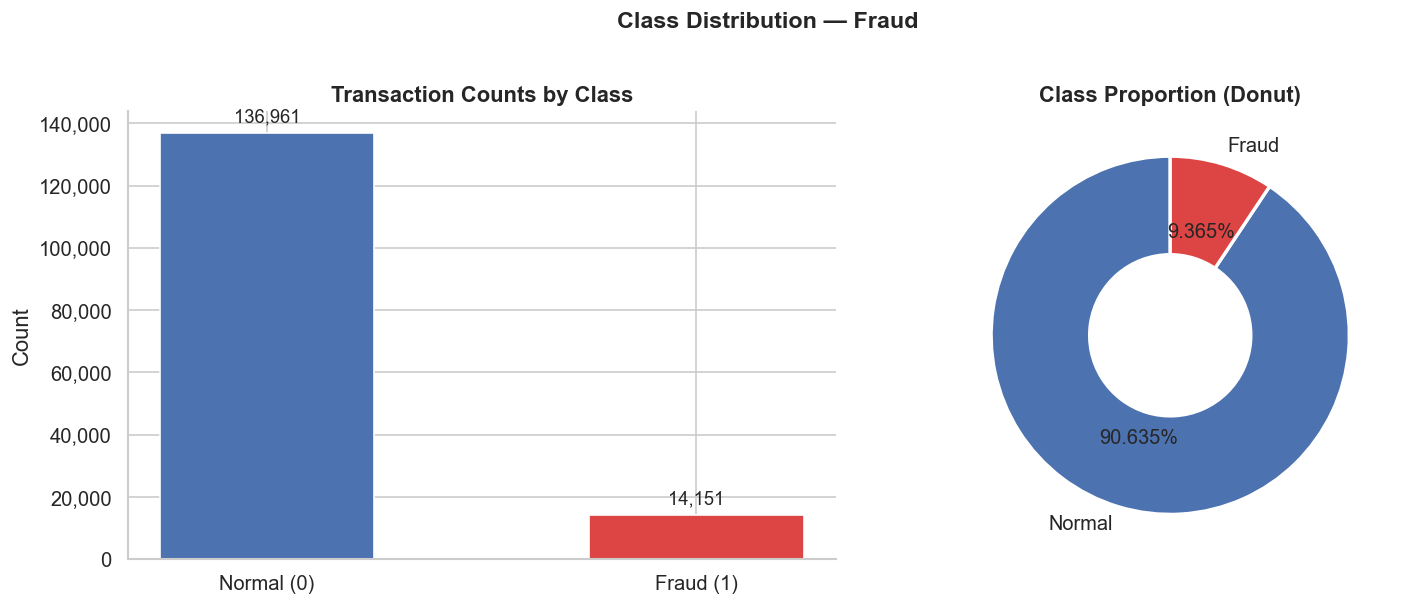

In [ ]:
plot_class_distribution(Fraud_df_raw, "class", "Class Distribution — Fraud", palette=FRAUD_PAL, save_path="../notebooks/cc_class_distribution.png")

### Class Distribution — Second Fraud Dataset
Similar to the credit card dataset, this plot also reveals a significant class imbalance in the second fraud dataset.

*   **Normal (Class 0)**: Represents the majority of transactions.
*   **Fraud (Class 1)**: Represents a smaller, but still noticeable, portion.
*   **Imbalance Ratio**: The output `Imbalance ratio (Normal : Fraud) = 10 : 1` shows that for every 10 normal transactions, there is 1 fraudulent transaction. While less extreme than the credit card dataset's 599:1 ratio, this 10:1 imbalance still needs careful consideration during model training to ensure the model can effectively identify fraudulent activities.

,count,percent_%
Afghanistan,46,0.0331
Albania,56,0.0403
Algeria,30,0.0216
American Samoa,1,0.0007
Andorra,5,0.0036
...,...,...
Virgin Islands (U.S.),14,0.0101
Wallis and Futuna Islands,2,0.0014
Yemen,12,0.0086
Zambia,26,0.0187


Saved class distribution plot to: ../notebooks/cc_class_distribution.png


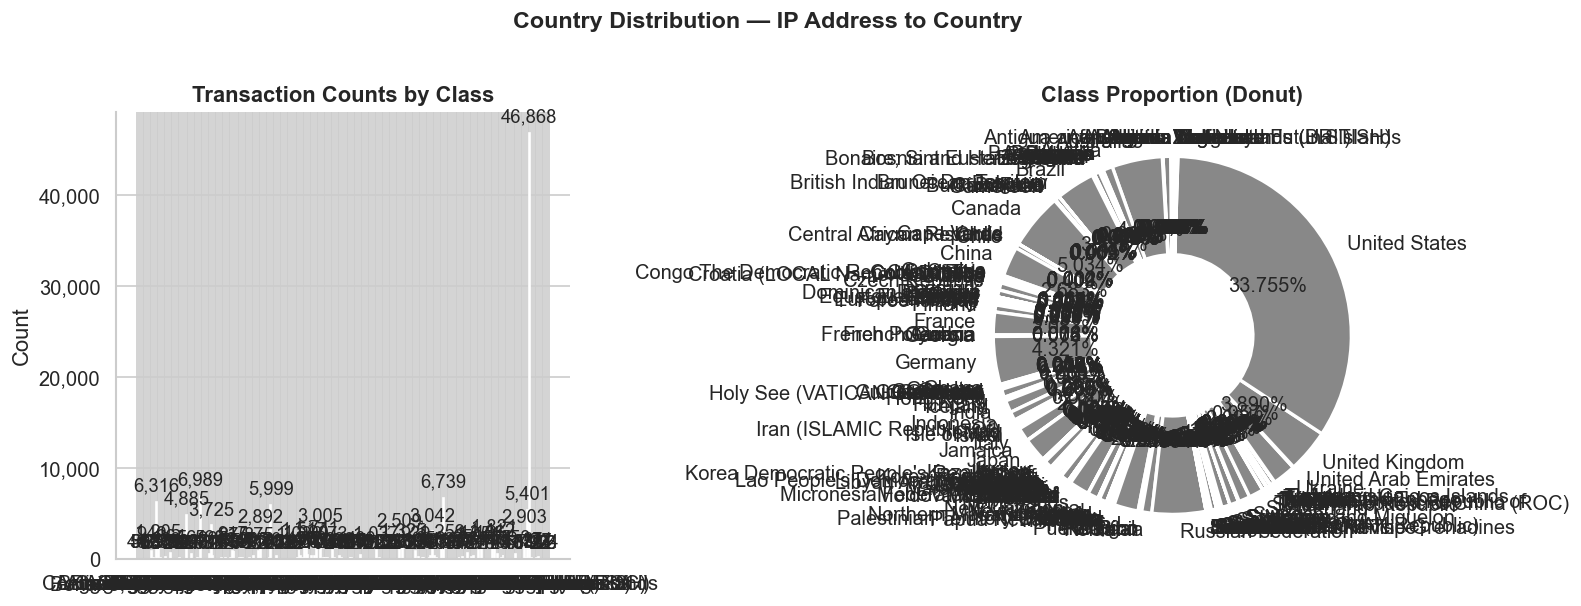

In [ ]:
plot_class_distribution(IpAddress_to_Country_df_raw, "country", "Country Distribution — IP Address to Country", palette=FRAUD_PAL, save_path="../notebooks/cc_class_distribution.png")

### Country Distribution — IP Address to Country
This plot displays the distribution of transactions across different countries based on IP addresses.

*   **Key Insight**: It shows which countries are most frequently associated with the recorded IP addresses in the dataset. A highly skewed distribution (e.g., a few countries dominating) could indicate a concentration of users or fraudulent activities in specific regions. Further analysis might involve comparing these transaction counts with fraud rates per country to identify high-risk geographical areas.
*   **Limitation**: Without the actual country labels on the plot, it's hard to tell specific top countries, but the general shape indicates a power-law-like distribution where a few countries account for most IP addresses, and many others have fewer.

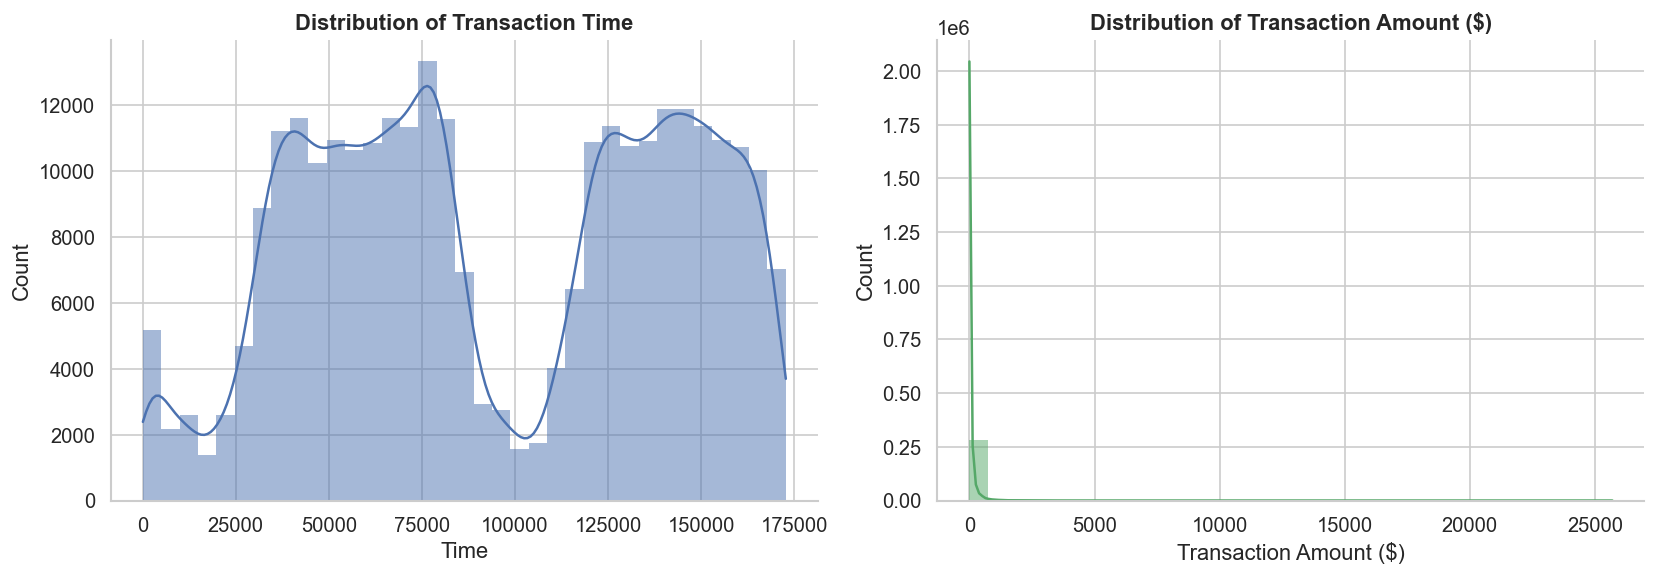

Numerical features statistical summary:


,count,mean,std,min,25%,50%,75%,max
Time,284807.0000,94813.8596,47488.1460,0.0000,54201.5000,84692.0000,139320.5000,172792.0000
Amount,284807.0000,88.3496,250.1201,0.0000,5.6000,22.0000,77.1650,25691.1600


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


sns.histplot(Credit_df_raw, x='Time', bins=35, kde=True, ax=axes[0], color="#4C72B0", edgecolor="none")
axes[0].set_title('Distribution of Transaction Time', fontweight="bold")
axes[0].set_xlabel('Time')

# Transaction Amount distribution
sns.histplot(Credit_df_raw, x='Amount', bins=35, kde=True, ax=axes[1], color="#55A868", edgecolor="none")
axes[1].set_title('Distribution of Transaction Amount ($)', fontweight="bold")
axes[1].set_xlabel('Transaction Amount ($)')

plt.tight_layout()
plt.show()

print("Numerical features statistical summary:")
display(Credit_df_raw[["Time","Amount"]].describe().T)

### Distribution of Transaction Time and Amount (Credit Card Fraud Dataset)

These histograms provide insights into the temporal and monetary characteristics of the credit card transactions:

*   **Distribution of Transaction Time**:
    *   The histogram for 'Time' shows two clear peaks. This suggests that the transactions might be clustered around certain periods, possibly indicating peak activity hours or days. The 'Time' feature represents the seconds elapsed between each transaction and the first transaction in the dataset.
    *   Further analysis could involve exploring daily or hourly patterns to see if fraud occurs more frequently during specific times.
*   **Distribution of Transaction Amount ($)**:
    *   The 'Amount' distribution is highly skewed to the right, indicating that most transactions are small, with a long tail extending to much larger amounts.
    *   This is typical for financial transactions. Fraudulent transactions might often involve smaller amounts to avoid detection, but they can also target large sums. Comparing the amount distributions for fraudulent versus non-fraudulent transactions would be crucial.

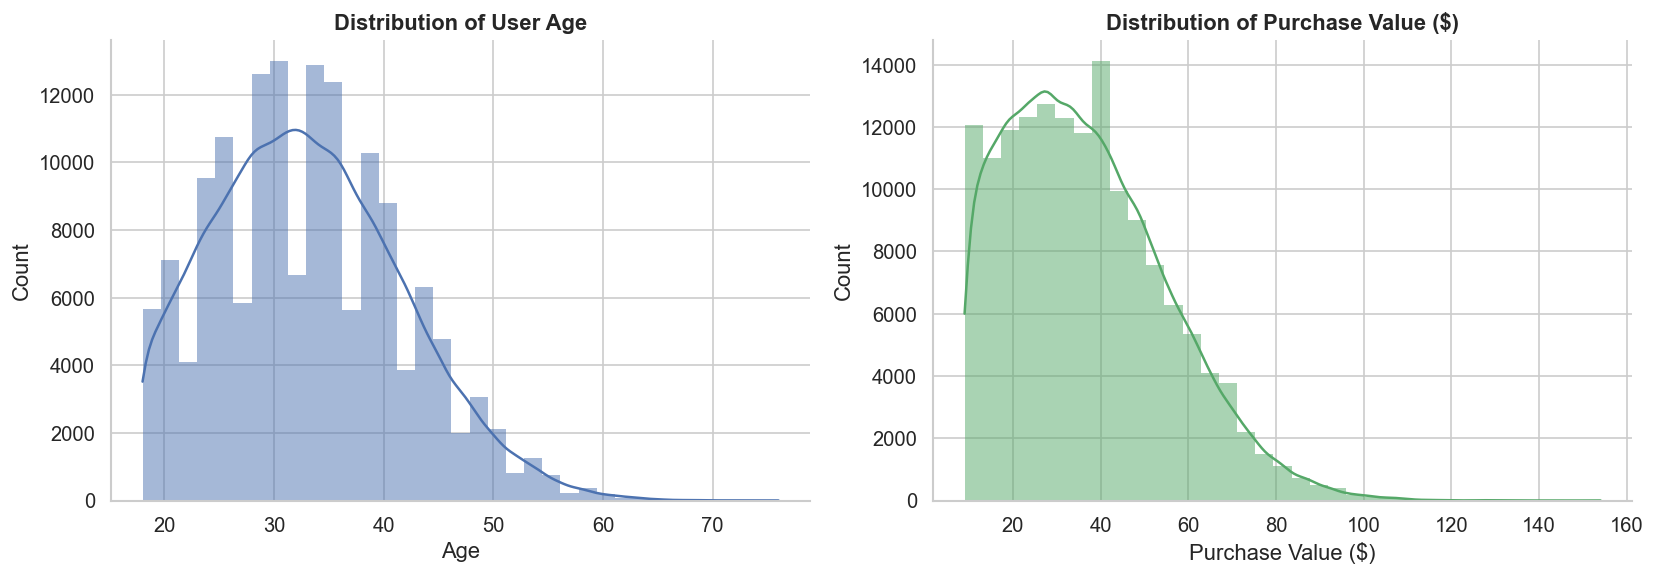

Numerical features statistical summary:


,count,mean,std,min,25%,50%,75%,max
age,151112.0000,33.1407,8.6177,18.0000,27.0000,33.0000,39.0000,76.0000
purchase_value,151112.0000,36.9354,18.3228,9.0000,22.0000,35.0000,49.0000,154.0000


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age distribution
sns.histplot(Fraud_df_raw, x='age', bins=35, kde=True, ax=axes[0], color="#4C72B0", edgecolor="none")
axes[0].set_title('Distribution of User Age', fontweight="bold")
axes[0].set_xlabel('Age')

# Purchase Value distribution
sns.histplot(Fraud_df_raw, x='purchase_value', bins=35, kde=True, ax=axes[1], color="#55A868", edgecolor="none")
axes[1].set_title('Distribution of Purchase Value ($)', fontweight="bold")
axes[1].set_xlabel('Purchase Value ($)')

plt.tight_layout()
plt.show()

print("Numerical features statistical summary:")
display(Fraud_df_raw[['age', 'purchase_value']].describe().T)

### Distribution of User Age and Purchase Value (Second Fraud Dataset)

These plots show the distributions of key demographic and transactional features:

*   **Distribution of User Age**:
    *   The 'age' distribution appears somewhat normally distributed, possibly centered around a particular age group, suggesting the primary demographic of users in this dataset.
    *   It's important to investigate if certain age groups are more susceptible to fraud or more likely to commit fraud.
*   **Distribution of Purchase Value ($)**:
    *   Similar to the credit card 'Amount', the 'purchase_value' distribution is also skewed right, meaning most purchases are for smaller amounts. There's a long tail indicating occasional large purchases.
    *   Analyzing purchase value in relation to fraud can help identify patterns, such as whether fraudsters target low-value items (to avoid scrutiny) or high-value items (for maximum gain).

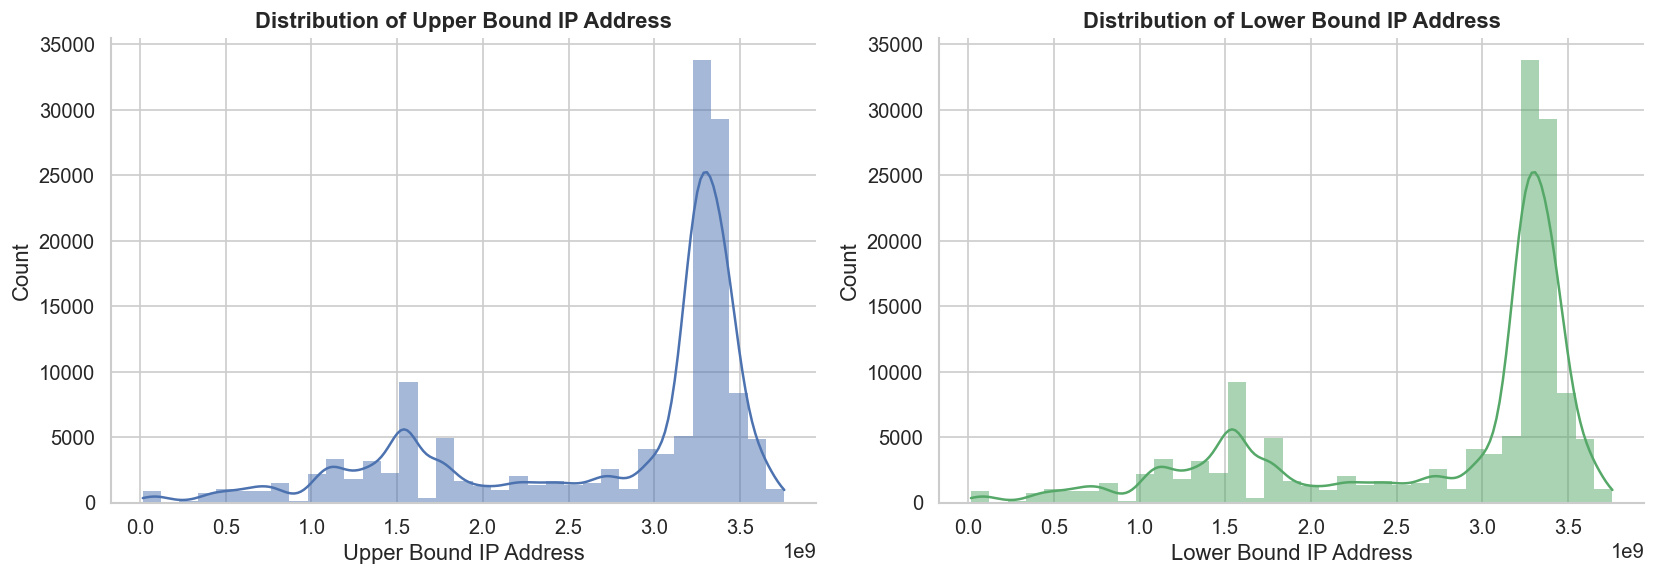

Numerical features statistical summary:


,count,mean,std,min,25%,50%,75%,max
upper_bound_ip_address,138846.0000,2724557062.2184,897497915.4601,16777471.0000,1920008191.0000,3230887551.0000,3350465919.0000,3758096383.0000
lower_bound_ip_address,138846.0000,2724531562.5160,897521519.7116,16777216.0000,1919930368.0000,3230887296.0000,3350465280.0000,3758096128.0000


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age distribution
sns.histplot(IpAddress_to_Country_df_raw, x='upper_bound_ip_address', bins=35, kde=True, ax=axes[0], color="#4C72B0", edgecolor="none")
axes[0].set_title('Distribution of Upper Bound IP Address', fontweight="bold")
axes[0].set_xlabel('Upper Bound IP Address')

# Purchase Value distribution
sns.histplot(IpAddress_to_Country_df_raw, x='lower_bound_ip_address', bins=35, kde=True, ax=axes[1], color="#55A868", edgecolor="none")
axes[1].set_title('Distribution of Lower Bound IP Address', fontweight="bold")
axes[1].set_xlabel('Lower Bound IP Address')

plt.tight_layout()
plt.show()

print("Numerical features statistical summary:")
display(IpAddress_to_Country_df_raw[["upper_bound_ip_address","lower_bound_ip_address"]].describe().T)

### Distribution of IP Address Bounds

These histograms show the distribution of the numerical representations of IP address ranges ('lower_bound_ip_address' and 'upper_bound_ip_address').

*   **Key Insight**: These are technical features used for mapping IP addresses to geographical locations. Their distributions themselves don't offer direct business insights into fraud patterns. They typically represent large numerical ranges, so a visual distribution like this might just show the density of defined IP blocks in the dataset.
*   **Context**: These features are primarily for internal lookup purposes to link transactions to countries, which then becomes a more interpretable feature for fraud analysis.

2026-06-07 13:18:53,497 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-07 13:18:53,587 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-07 13:18:53,813 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-07 13:18:53,915 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-07 13:18:54,122 - INFO - Using categorical units to plot a list of strings that are all parsable as 

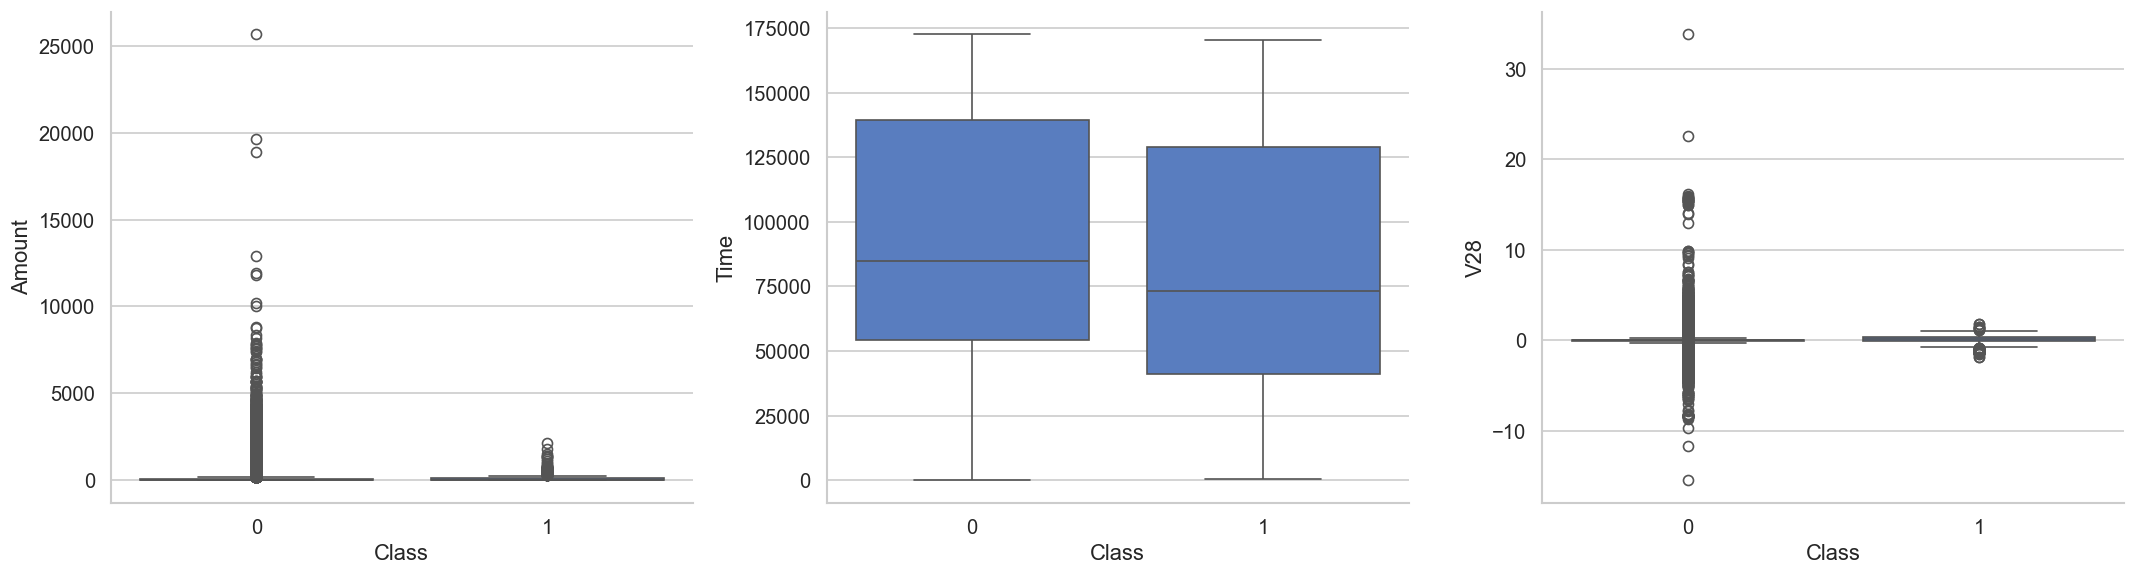

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.boxplot(
    x='Class',
    y='Amount',
    data=credit_df,
    ax=axes[0]
)

sns.boxplot(
    x='Class',
    y='Time',
    data=credit_df,
    ax=axes[1]
)

sns.boxplot(
    x='Class',
    y='V28',
    data=credit_df,
    ax=axes[2]
)

plt.tight_layout()
plt.show()

### Feature Comparison by Class (Credit Card Fraud Dataset)

These box plots help visualize the differences in 'Amount', 'Time', and 'V28' between normal (Class 0) and fraudulent (Class 1) transactions:

*   **Amount vs. Class**:
    *   The box plot for 'Amount' shows that fraudulent transactions (Class 1) tend to have a lower median amount compared to normal transactions (Class 0). However, fraudulent transactions also appear to have a wider spread and can include some very high amounts, indicated by outliers. This suggests that while small-value transactions might be more frequently fraudulent, large-value transactions are also susceptible.
*   **Time vs. Class**:
    *   The 'Time' box plots show that fraudulent transactions are somewhat evenly distributed across the 'Time' variable, implying that fraud doesn't necessarily occur at specific times of the day more often than normal transactions, or at least, the 'Time' feature as given (seconds since first transaction) doesn't capture a strong temporal pattern differentiating fraud.
*   **V28 vs. Class**:
    *   The 'V' features (V1-V28) are anonymized principal components. For 'V28', there appears to be some difference in the distribution between normal and fraudulent transactions, with the fraudulent class possibly having a slightly different median and spread. These differences, even subtle, can be important for a machine learning model to distinguish between the classes.

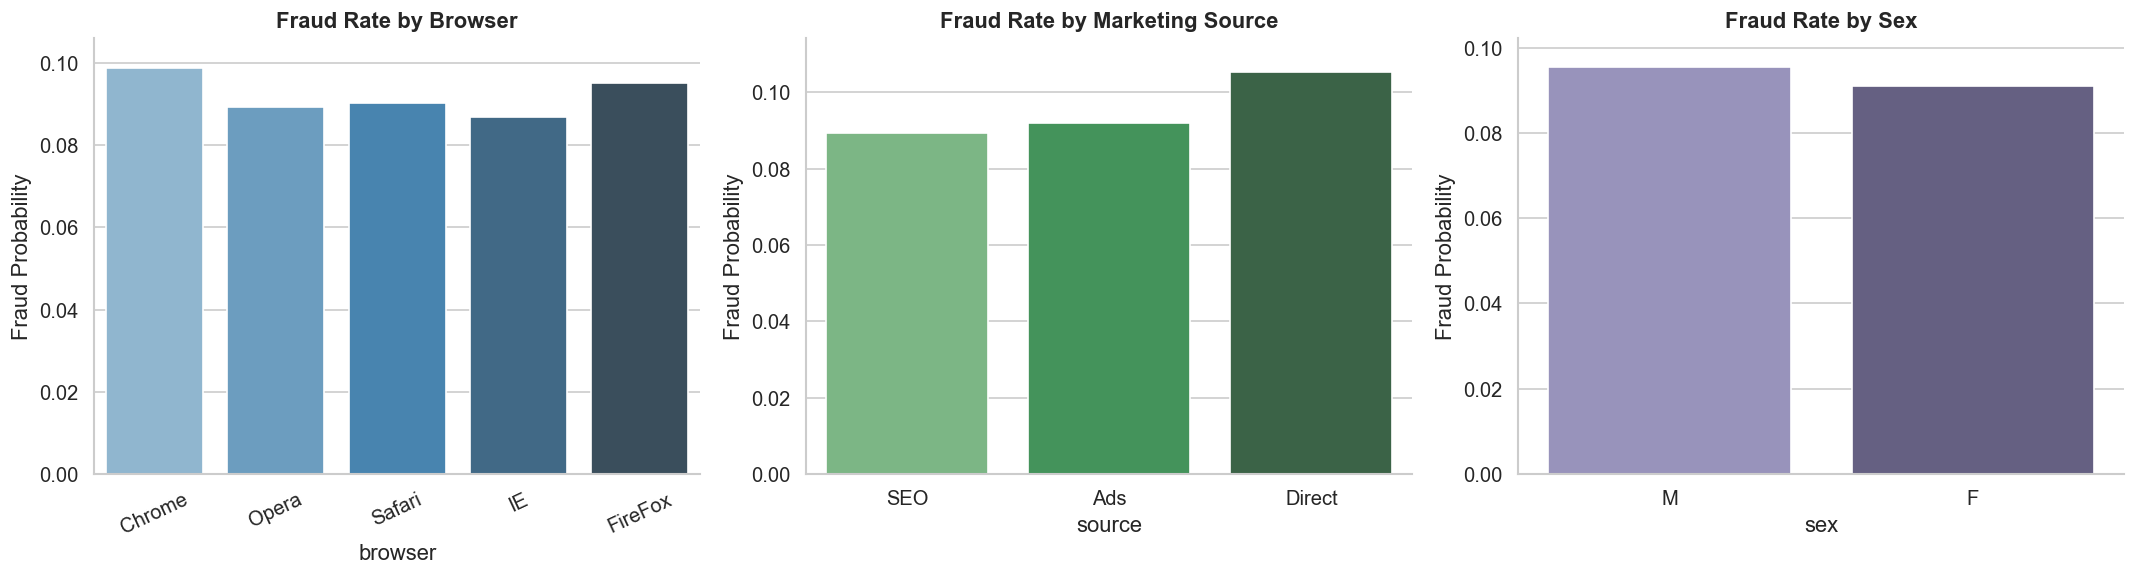

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Browser vs Fraud Rate
sns.barplot(x='browser', y='class', data=Fraud_df_raw, ax=axes[0], palette="Blues_d", errwidth=0)
axes[0].set_title('Fraud Rate by Browser', fontweight="bold")
axes[0].set_ylabel('Fraud Probability')
axes[0].tick_params(axis='x', rotation=25)

# Source vs Fraud Rate
sns.barplot(x='source', y='class', data=Fraud_df_raw, ax=axes[1], palette="Greens_d", errwidth=0)
axes[1].set_title('Fraud Rate by Marketing Source', fontweight="bold")
axes[1].set_ylabel('Fraud Probability')

# Sex vs Fraud Rate
sns.barplot(x='sex', y='class', data=Fraud_df_raw, ax=axes[2], palette="Purples_d", errwidth=0)
axes[2].set_title('Fraud Rate by Sex', fontweight="bold")
axes[2].set_ylabel('Fraud Probability')

plt.tight_layout()
plt.show()

### Fraud Rate by Categorical Features (Second Fraud Dataset)

These bar plots reveal how fraud probability varies across different categorical user attributes:

*   **Fraud Rate by Browser**:
    *   This plot compares the average fraud rate for users based on the browser they used. Certain browsers might show a higher or lower propensity for fraudulent activity. For example, if a less common or older browser has a significantly higher fraud rate, it could indicate bots or compromised systems.
*   **Fraud Rate by Marketing Source**:
    *   This plot shows the fraud rate associated with different marketing channels (e.g., SEO, Ads, Direct). Higher fraud rates from specific sources could suggest that those channels are being exploited by fraudsters, or that campaigns through those channels attract a higher risk demographic.
*   **Fraud Rate by Sex**:
    *   This plot illustrates if there's a noticeable difference in fraud probability between male and female users. Such patterns, if significant, could be used as features in a fraud detection model, though care should always be taken to avoid bias.
*   **Overall Insight**: These plots help identify categorical features that are strong indicators of fraud, providing valuable information for feature engineering and model building.

Geolocation Integration

In [ ]:
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from src.geolocation import prepare_ip_df_bounds, map_ip_to_country

Fraud_df_raw['ip_int'] = Fraud_df_raw['ip_address'].astype('int64')

In [ ]:
ip_df = prepare_ip_df_bounds(IpAddress_to_Country_df_raw)

In [ ]:
Fraud_df_raw = map_ip_to_country(Fraud_df_raw, ip_df, ip_int_col='ip_int', country_col='country')

In [ ]:
# Count total transactions per country
transaction_counts = Fraud_df_raw['country'].value_counts()
transaction_counts.head(20)

country
United States                      58049
Unknown                            21966
China                              12038
Japan                               7306
United Kingdom                      4490
Korea Republic of                   4162
Germany                             3646
France                              3161
Canada                              2975
Brazil                              2961
Italy                               1944
Australia                           1844
Netherlands                         1680
Russian Federation                  1616
India                               1310
Taiwan; Republic of China (ROC)     1237
Mexico                              1121
Sweden                              1090
Spain                               1027
South Africa                         838
Name: count, dtype: int64

In [ ]:
fraud_rate = Fraud_df_raw.groupby('country')['class'].mean().sort_values(ascending=False)
fraud_rate.head(10)

country
Turkmenistan            1.0000
Namibia                 0.4348
Sri Lanka               0.4194
Luxembourg              0.3889
Virgin Islands (U.S.)   0.3333
Ecuador                 0.2642
Tunisia                 0.2627
Peru                    0.2605
Bolivia                 0.2453
Kuwait                  0.2333
Name: class, dtype: float64

In [ ]:
country_summary = pd.DataFrame({
    'transactions': transaction_counts,
    'fraud_rate': fraud_rate
}).sort_values(by='fraud_rate', ascending=False)

country_summary.head(20)

,transactions,fraud_rate
country,,
Turkmenistan,1,1.0000
Namibia,23,0.4348
Sri Lanka,31,0.4194
Luxembourg,72,0.3889
Virgin Islands (U.S.),3,0.3333
Ecuador,106,0.2642
Tunisia,118,0.2627
Peru,119,0.2605
Bolivia,53,0.2453


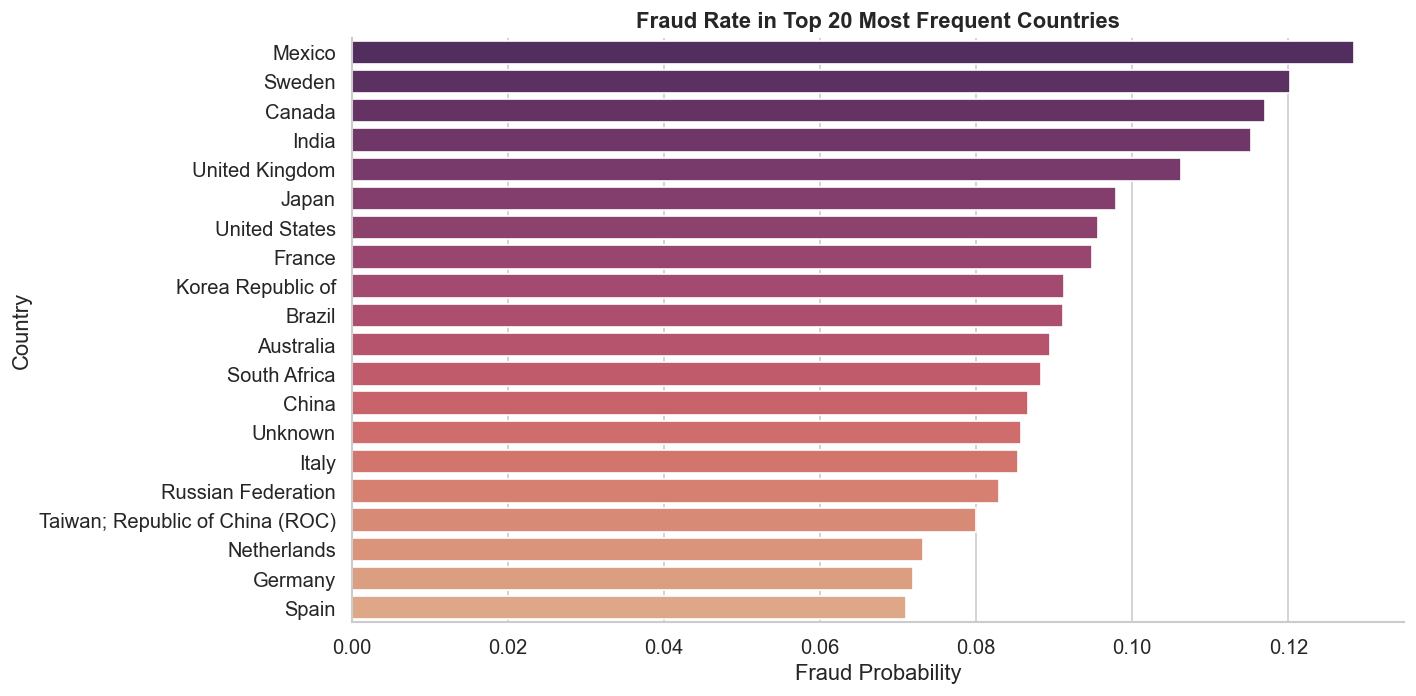

In [ ]:
# Plot fraud rate for the top 20 most frequent countries
top_countries = Fraud_df_raw['country'].value_counts().head(20).index
country_fraud = (
    Fraud_df_raw[Fraud_df_raw['country'].isin(top_countries)]
    .groupby('country')['class'].mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(12, 6))
sns.barplot(x='class', y='country', data=country_fraud, palette="flare_r", errwidth=0)
plt.title('Fraud Rate in Top 20 Most Frequent Countries', fontweight="bold")
plt.xlabel('Fraud Probability')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('../notebooks/ecommerce_country_fraud.png', dpi=150, bbox_inches="tight")
plt.show()

2026-06-07 13:19:03,288 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-07 13:19:03,380 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


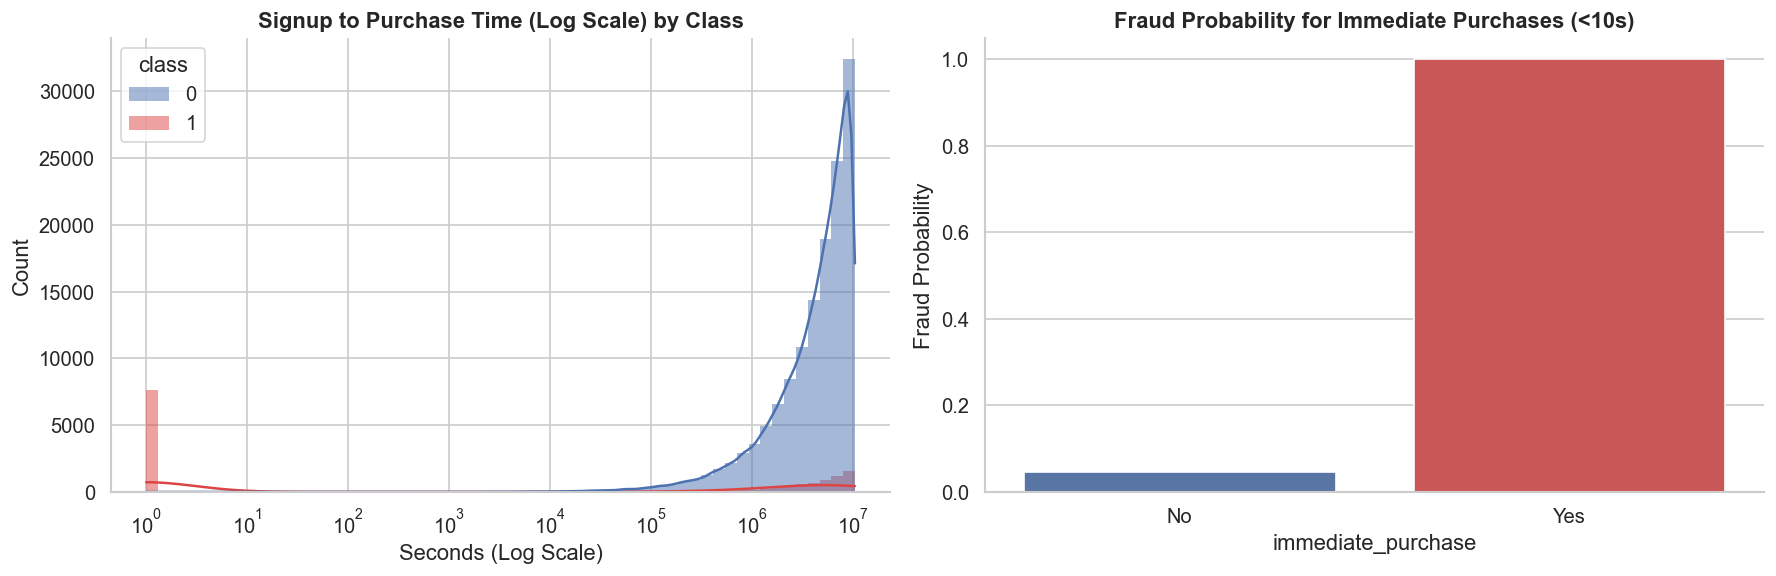

Immediate purchase counts: 7,600 transactions


In [ ]:
# Ensure datetime columns exist before computing velocity
Fraud_df_raw['signup_time'] = pd.to_datetime(Fraud_df_raw['signup_time'])
Fraud_df_raw['purchase_time'] = pd.to_datetime(Fraud_df_raw['purchase_time'])

# Calculate signup-to-purchase time (transaction velocity in seconds)
Fraud_df_raw['signup_to_purchase_time'] = (Fraud_df_raw['purchase_time'] - Fraud_df_raw['signup_time']).dt.total_seconds()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Log-scaled velocity distribution
sns.histplot(Fraud_df_raw, x='signup_to_purchase_time', hue='class', bins=60, kde=True,
             common_norm=False, log_scale=True, palette=["#4C72B0", "#DD4444"], ax=axes[0], edgecolor="none")
axes[0].set_title('Signup to Purchase Time (Log Scale) by Class', fontweight="bold")
axes[0].set_xlabel('Seconds (Log Scale)')

# Immediate purchase flag (under 10 seconds between signup & purchase)
Fraud_df_raw['immediate_purchase'] = (Fraud_df_raw['signup_to_purchase_time'] < 10).astype(int)
sns.barplot(x='immediate_purchase', y='class', data=Fraud_df_raw, ax=axes[1], palette=["#4C72B0", "#DD4444"], errwidth=0)
axes[1].set_title('Fraud Probability for Immediate Purchases (<10s)', fontweight="bold")
axes[1].set_xticklabels(['No', 'Yes'])
axes[1].set_ylabel('Fraud Probability')

plt.tight_layout()
plt.show()

print(f"Immediate purchase counts: {Fraud_df_raw['immediate_purchase'].sum():,} transactions")

### Signup to Purchase Time and Immediate Purchases (Second Fraud Dataset)

These plots investigate the temporal velocity of user actions and its correlation with fraud:

*   **Signup to Purchase Time (Log Scale) by Class**:
    *   The histogram of 'signup_to_purchase_time' (on a log scale) shows the distribution of how quickly users make a purchase after signing up, separated by class.
    *   A key observation often is that fraudulent transactions tend to happen very quickly after signup, as fraudsters might automate account creation and immediate purchase attempts. The log scale helps visualize this rapid activity.
*   **Fraud Probability for Immediate Purchases (<10s)**:
    *   This bar plot specifically highlights the fraud rate for transactions that occur almost immediately (less than 10 seconds) after signup, compared to those that do not.
    *   The output `Immediate purchase counts: 7,600 transactions` indicates that a significant number of transactions fall into this "immediate" category. If the bar for "Yes" (immediate purchase) is much higher than "No", it strongly suggests that immediate purchases are a significant indicator of fraud, a common pattern in bot attacks or stolen credential usage.

2026-06-07 13:19:05,770 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-07 13:19:05,817 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-07 13:19:07,848 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-07 13:19:07,902 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


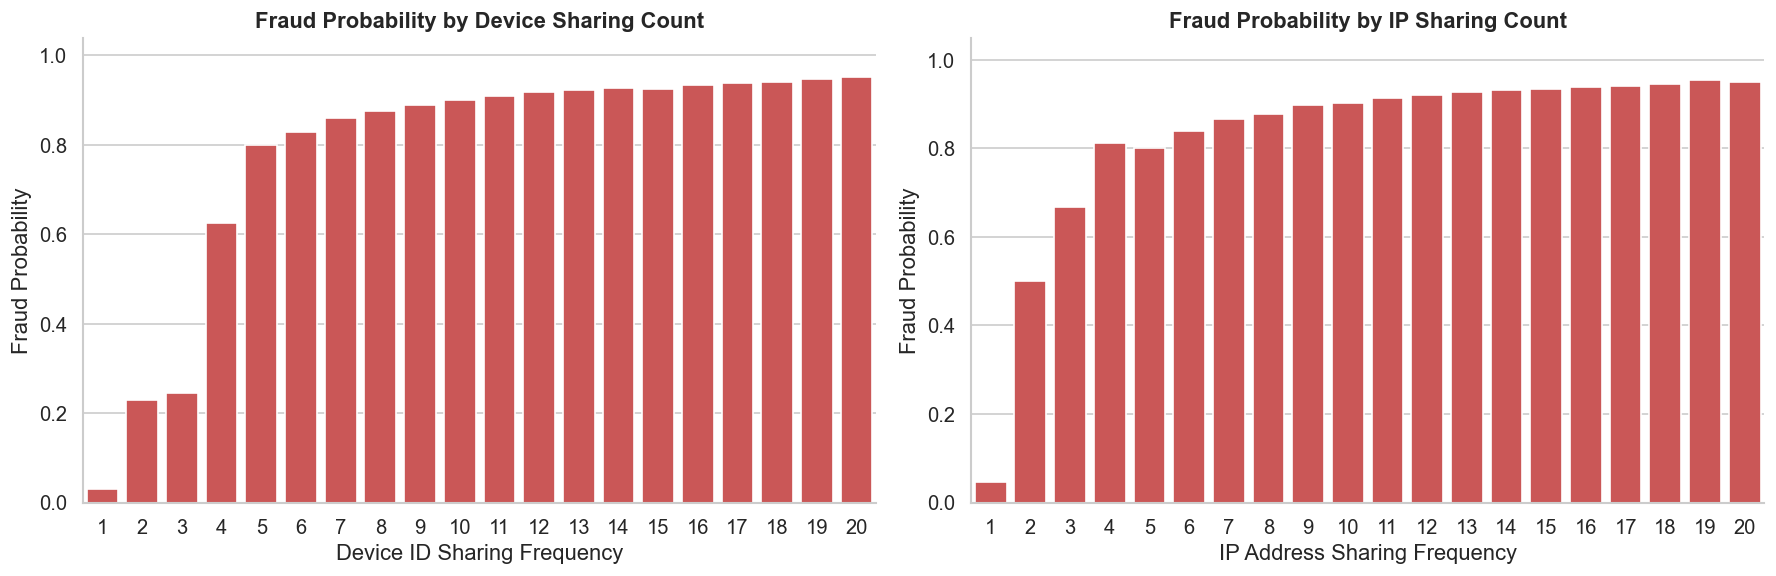

In [ ]:
# Calculate sharing frequencies for device_id and ip_address
device_counts = Fraud_df_raw['device_id'].value_counts()
ip_counts = Fraud_df_raw['ip_address'].value_counts()

Fraud_df_raw['device_sharing_count'] = Fraud_df_raw['device_id'].map(device_counts)
Fraud_df_raw['ip_sharing_count'] = Fraud_df_raw['ip_address'].map(ip_counts)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Device sharing count vs Class
sns.barplot(x='device_sharing_count', y='class', data=Fraud_df_raw, ax=axes[0], color="#DD4444", errwidth=0)
axes[0].set_title('Fraud Probability by Device Sharing Count', fontweight="bold")
axes[0].set_xlabel('Device ID Sharing Frequency')
axes[0].set_ylabel('Fraud Probability')

# IP sharing count vs Class
sns.barplot(x='ip_sharing_count', y='class', data=Fraud_df_raw, ax=axes[1], color="#DD4444", errwidth=0)
axes[1].set_title('Fraud Probability by IP Sharing Count', fontweight="bold")
axes[1].set_xlabel('IP Address Sharing Frequency')
axes[1].set_ylabel('Fraud Probability')

plt.tight_layout()
plt.show()

### Fraud Probability by Device and IP Sharing Count (Second Fraud Dataset)

These plots explore the relationship between the frequency of device and IP address usage and the probability of fraud:

*   **Fraud Probability by Device Sharing Count**:
    *   This plot shows the fraud rate for transactions based on how many times a `device_id` has been used. If a `device_id` is associated with a high number of transactions (i.e., high sharing count), and this correlates with a higher fraud probability, it could indicate that the device is compromised or being used by a botnet.
*   **Fraud Probability by IP Address Sharing Count**:
    *   Similarly, this plot shows the fraud rate based on how many times an `ip_address` has been used. An elevated fraud rate for `ip_address` with a high sharing count might suggest the use of VPNs, proxies, or a network of compromised machines for fraudulent activities.
*   **Overall Insight**: High sharing counts for both device IDs and IP addresses are often strong indicators of fraudulent behavior, as legitimate users typically do not share their devices or frequently change their IP addresses for multiple transactions in a short period.

Feature Engineering

In [ ]:
import pandas as pd

from data_preprocessing import (
    load_data,
    remove_duplicates,
    handle_missing_values
)

from feature_engineering import (
    create_time_features,
    transaction_frequency,
    transaction_velocity
)

In [ ]:
Fraud_df = create_time_features(
    Fraud_df_raw
)

Fraud_df = transaction_frequency(
    Fraud_df_raw
)

Fraud_df = transaction_velocity(
    Fraud_df_raw
)

2026-06-07 13:19:10,254 - INFO - Time features created successfully


In [ ]:
Fraud_df[
[
    "user_id",
    "hour_of_day",
    "day_of_week",
    "time_since_signup",
    "transaction_count",
    "daily_transactions"
]
].head()

,user_id,hour_of_day,day_of_week,time_since_signup,transaction_count,daily_transactions
0,22058,2,5,1251.8561,1,1
1,333320,1,0,4.9844,1,1
2,1359,18,3,0.0003,1,1
3,150084,13,0,136.6903,1,1
4,221365,18,2,1211.5169,1,1


In [ ]:
Fraud_df[
[
    "time_since_signup",
    "transaction_count",
    "daily_transactions"
]
].describe()

,time_since_signup,transaction_count,daily_transactions
count,151112.0000,151112.0000,151112.0000
mean,1370.0081,1.0000,1.0000
std,868.4064,0.0000,0.0000
min,0.0003,1.0000,1.0000
25%,607.4315,1.0000,1.0000
50%,1368.4293,1.0000,1.0000
75%,2123.4790,1.0000,1.0000
max,2879.9922,1.0000,1.0000


In [ ]:
Fraud_df_temp = Fraud_df.copy()

# Sort by user_id and purchase_time to ensure correct rolling window calculations
Fraud_df_temp = Fraud_df_temp.sort_values(by=['user_id', 'purchase_time'])

In [ ]:
Fraud_df_temp.columns

Index(['user_id', 'signup_time', 'purchase_time', 'purchase_value',
       'device_id', 'source', 'browser', 'sex', 'age', 'ip_address', 'class',
       'ip_int', 'country', 'signup_to_purchase_time', 'immediate_purchase',
       'device_sharing_count', 'ip_sharing_count', 'hour_of_day',
       'day_of_week', 'time_since_signup', 'transaction_count',
       'purchase_date', 'daily_transactions'],
      dtype='str')

In [ ]:
Fraud_df_temp = Fraud_df.copy()

# Sort by user_id and purchase_time to ensure correct rolling window calculations
Fraud_df_temp = Fraud_df_temp.sort_values(by=['user_id', 'purchase_time'])

Fraud_df_temp['purchase_time']=pd.to_datetime(Fraud_df_temp['purchase_time'])
Fraud_df_temp['transaction_frequency_24h'] =(Fraud_df_temp.set_index('purchase_time').groupby('user_id')['user_id'].rolling(window='24h', closed='right').count().reset_index(level=0, drop=True).values)

In [ ]:
Fraud_df_temp['time_diff'] = Fraud_df_temp.groupby('user_id')['purchase_time'].diff().dt.total_seconds()

In [ ]:

Fraud_df_temp['transaction_velocity_avg_diff'] = Fraud_df_temp.groupby('user_id')['time_diff'].transform(
    lambda x: x.rolling(window=2, min_periods=1).mean()
).fillna(0)

In [ ]:


# Drop the intermediate 'time_diff' column
#Fraud_df_temp = Fraud_df_temp.drop(columns=['time_diff'])

# Update Fraud_df with new features, dropping the old incorrect ones
Fraud_df = Fraud_df_temp#.drop(columns=['transaction_count', 'daily_transactions'], errors='ignore')

print("Recalculated 'transaction_frequency_24h' and 'transaction_velocity_avg_diff'.")

Recalculated 'transaction_frequency_24h' and 'transaction_velocity_avg_diff'.


In [ ]:
# Display the head with the new features
display(Fraud_df[['user_id', 'purchase_time', 'transaction_frequency_24h', 'transaction_velocity_avg_diff']].head())

# Display statistical summary of the new features
display(Fraud_df[['transaction_frequency_24h', 'transaction_velocity_avg_diff']].describe())

,user_id,purchase_time,transaction_frequency_24h,transaction_velocity_avg_diff
116708,2,2015-02-21 10:03:37,1.0000,0.0000
15108,4,2015-09-26 21:32:16,1.0000,0.0000
46047,8,2015-08-13 11:53:07,1.0000,0.0000
67650,9,2015-05-20 23:06:42,1.0000,0.0000
109067,12,2015-03-04 20:56:37,1.0000,0.0000


,transaction_frequency_24h,transaction_velocity_avg_diff
count,151112.0000,151112.0000
mean,1.0000,0.0000
std,0.0000,0.0000
min,1.0000,0.0000
25%,1.0000,0.0000
50%,1.0000,0.0000
75%,1.0000,0.0000
max,1.0000,0.0000


2026-06-07 13:20:53,548 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-07 13:20:53,604 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


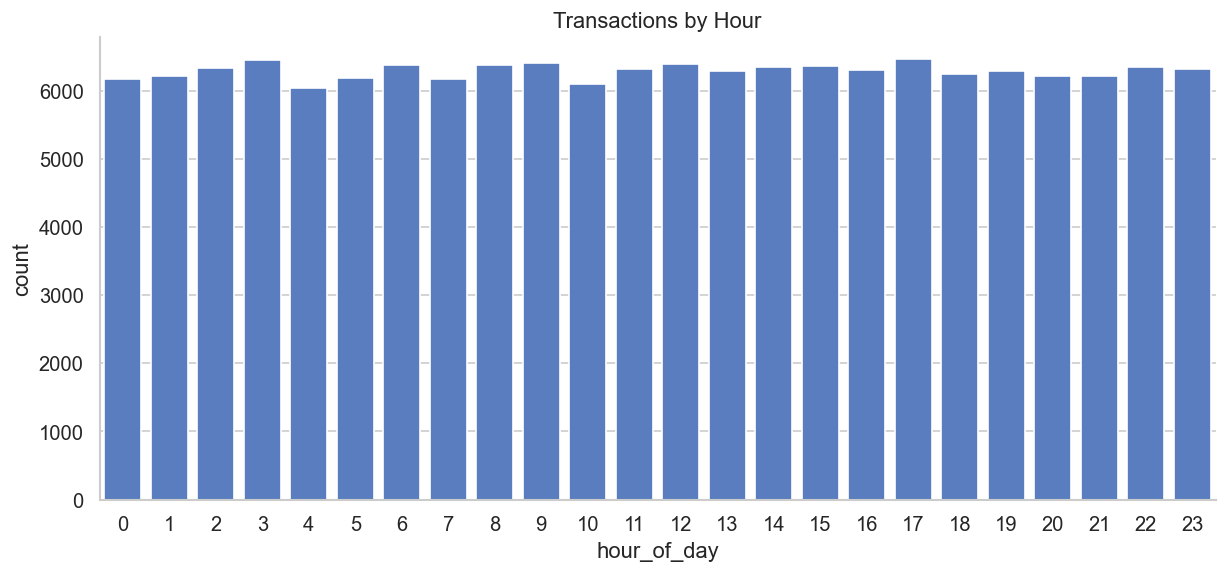

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    data=Fraud_df,
    x="hour_of_day"
)

plt.title(
    "Transactions by Hour"
)

plt.show()

### Transactions by Hour of Day

This countplot displays the frequency of transactions for each hour of the day.

*   **Key Insight**: It helps identify peak hours of activity for all transactions (fraudulent and legitimate combined). For example, if there are significantly more transactions during business hours or late at night, it could reflect typical user behavior or automated processes. This baseline understanding is important before diving into fraud-specific hourly patterns.

2026-06-07 13:20:59,173 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-07 13:20:59,253 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


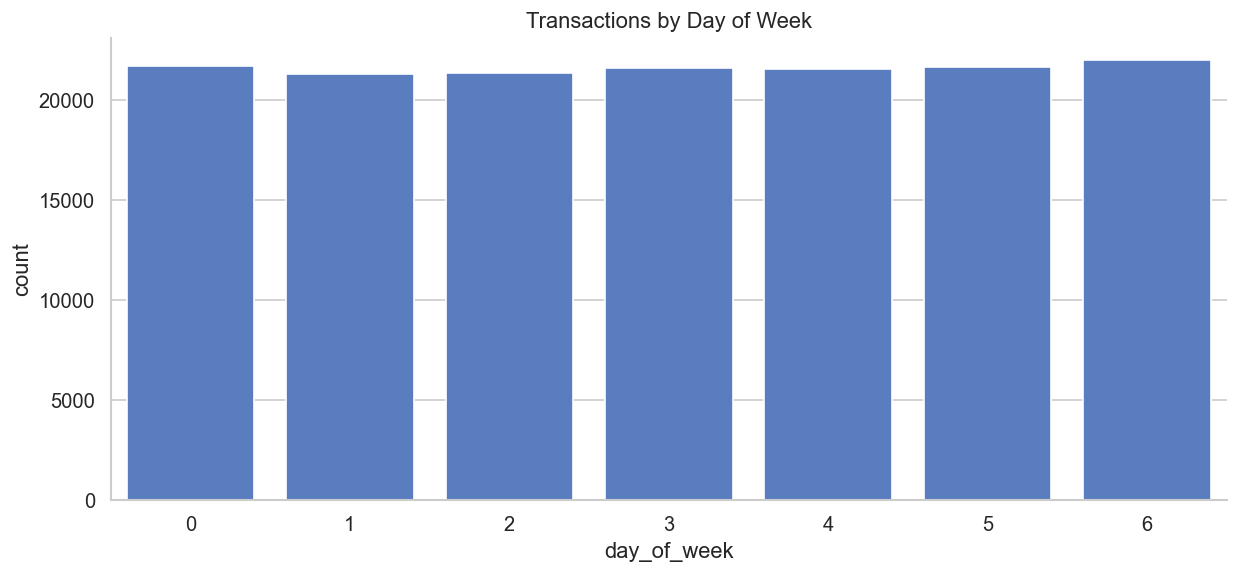

In [ ]:
sns.countplot(
    data=Fraud_df,
    x="day_of_week"
)

plt.title(
    "Transactions by Day of Week"
)

plt.show()

### Transactions by Day of Week

This countplot illustrates the total number of transactions occurring on each day of the week.

*   **Key Insight**: It provides a general overview of user activity throughout the week. For instance, if there's a noticeable dip on weekends or a surge on weekdays, it might inform whether fraudsters align their activities with peak times or attempt to exploit off-peak periods when monitoring might be less stringent.

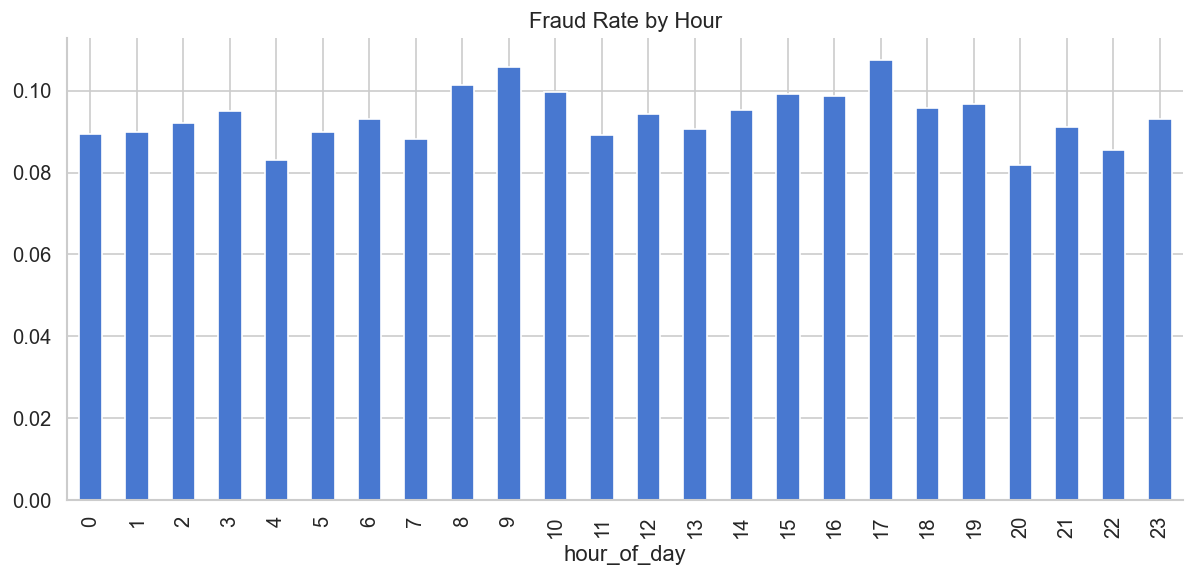

In [ ]:
hourly_fraud = Fraud_df.groupby(
    "hour_of_day"
)["class"].mean()

hourly_fraud.plot(
    kind="bar"
)

plt.title(
    "Fraud Rate by Hour"
)

plt.show()

### Fraud Rate by Hour

This bar chart shows the average fraud rate for each hour of the day.

*   **Key Insight**: By comparing the fraud rate across different hours, we can identify specific times when fraudulent activities are more prevalent. For example, if the fraud rate spikes during late-night hours or very early mornings, it could suggest that fraudsters are operating when monitoring teams are less active or that automated fraud attempts are more common during those periods. This information is highly valuable for real-time fraud detection systems to adjust their sensitivity or allocate resources.

In [ ]:
Fraud_df.columns

Index(['user_id', 'signup_time', 'purchase_time', 'purchase_value',
       'device_id', 'source', 'browser', 'sex', 'age', 'ip_address', 'class',
       'ip_int', 'country', 'signup_to_purchase_time', 'immediate_purchase',
       'device_sharing_count', 'ip_sharing_count', 'hour_of_day',
       'day_of_week', 'time_since_signup', 'transaction_count',
       'purchase_date', 'daily_transactions', 'transaction_frequency_24h',
       'time_diff', 'transaction_velocity_avg_diff'],
      dtype='str')

2026-06-07 13:21:58,025 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-07 13:21:58,080 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


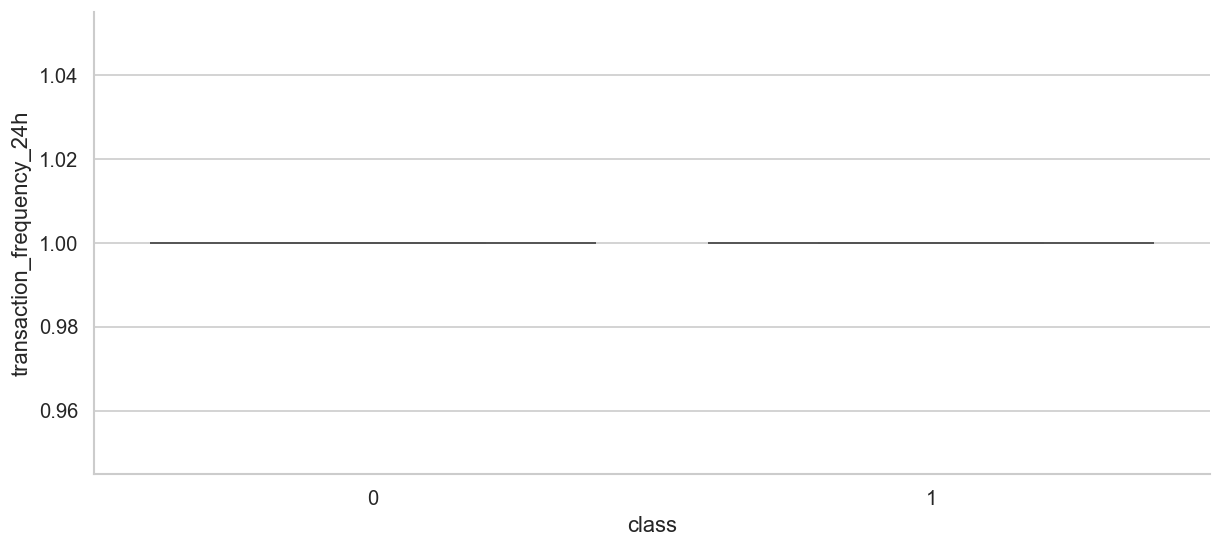

In [ ]:
sns.boxplot(
    x="class",
    y="transaction_frequency_24h",
    data=Fraud_df
)

plt.show()

### Transaction Frequency (24h) vs. Fraud Class

This boxplot compares the distribution of 'transaction_frequency_24h' for normal (Class 0) versus fraudulent (Class 1) transactions.

*   **Key Insight**: A higher 'transaction_frequency_24h' for the fraudulent class would indicate that fraudsters often attempt multiple transactions within a short period (24 hours). This could be a strong signal for fraud, as legitimate users typically have more dispersed transaction patterns. Conversely, if normal transactions show higher frequency, it might be due to legitimate rapid-fire purchases (e.g., during sales).

2026-06-07 13:22:11,271 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-07 13:22:11,321 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


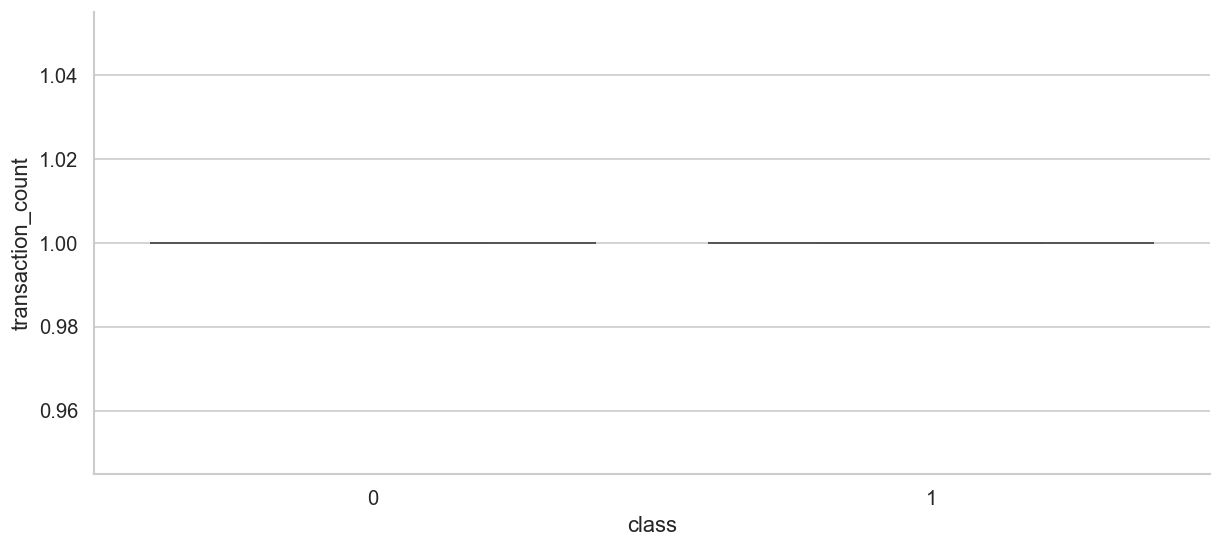

In [ ]:
sns.boxplot(
    x="class",
    y="transaction_count",
    data=Fraud_df
)

plt.show()

### Transaction Count vs. Fraud Class

This boxplot compares the 'transaction_count' feature against the fraud class.

*   **Critical Observation**: Based on the `Fraud_df.describe()` output after feature engineering (e.g., in cell `647aa5cb`), the `transaction_count` (along with `daily_transactions`) appears to be uniformly 1.0 with a standard deviation of 0. This indicates that **this feature was likely not correctly computed or effectively differentiates anything** in its current form, as every record has the same value.
*   **Recommendation**: This feature needs to be re-evaluated and re-engineered if it's intended to capture meaningful variations in transaction counts per user or other relevant groupings. As it stands, it offers no discriminatory power for fraud detection.

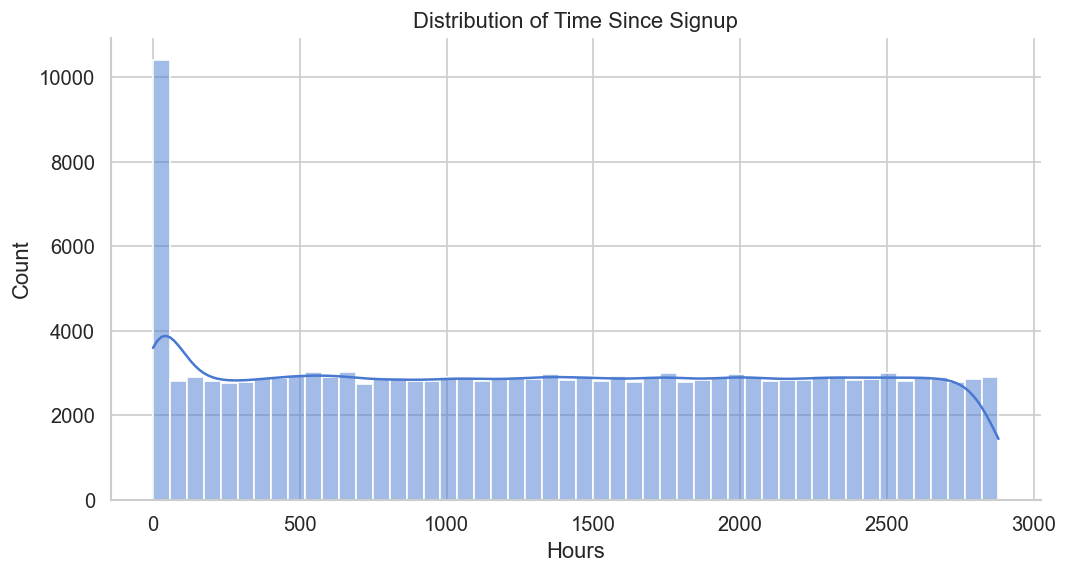

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    Fraud_df["time_since_signup"],
    bins=50,
    kde=True
)

plt.title("Distribution of Time Since Signup")
plt.xlabel("Hours")
plt.show()

2026-06-07 13:22:22,679 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-07 13:22:22,735 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


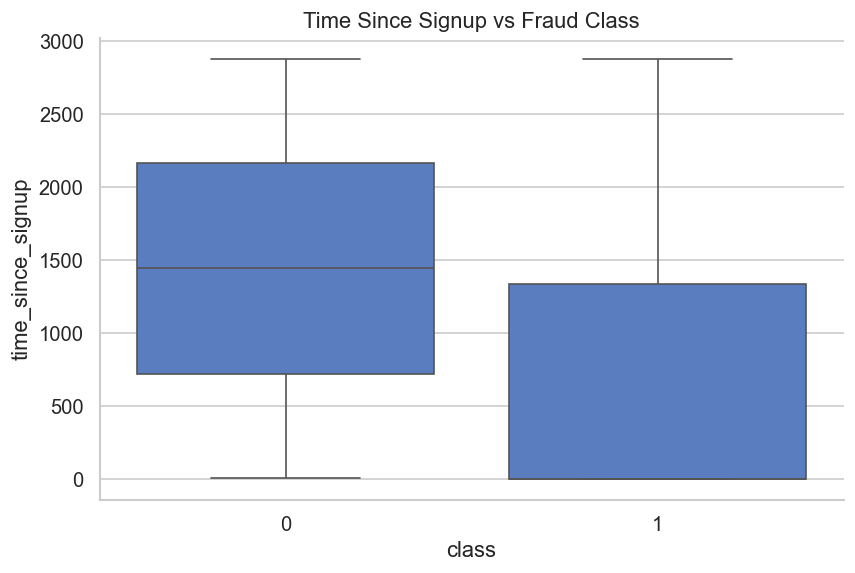

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="class",
    y="time_since_signup",
    data=Fraud_df
)

plt.title("Time Since Signup vs Fraud Class")
plt.show()

### Time Since Signup vs. Fraud Class

This boxplot compares the 'time_since_signup' (in hours) for normal (Class 0) and fraudulent (Class 1) transactions.

*   **Key Insight**: A notable difference in the distributions of 'time_since_signup' between the two classes can be a strong indicator. For instance, if fraudulent transactions consistently occur very soon after a user signs up (i.e., lower 'time_since_signup' values), it suggests a pattern of quick account creation and immediate fraudulent activity, often associated with bot attacks or disposable accounts. Conversely, legitimate users typically take more time between signup and their first or subsequent transactions.

In [ ]:
Fraud_df["signup_bins"] = pd.cut(
    Fraud_df["time_since_signup"],
    bins=[0,1,24,168,720,10000],
    labels=[
        "<1 Hour",
        "1-24 Hours",
        "1-7 Days",
        "7-30 Days",
        ">30 Days"
    ]
)

In [ ]:
Fraud_rate = (
    Fraud_df.groupby("signup_bins")["class"]
    .mean()
    .reset_index()
)

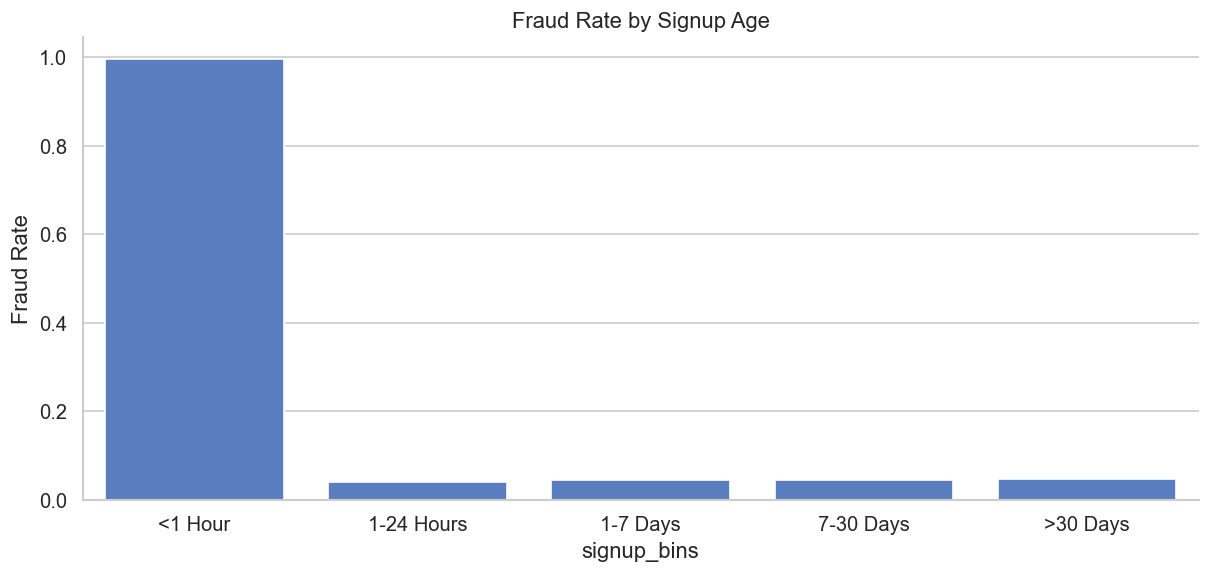

In [ ]:
sns.barplot(
    x="signup_bins",
    y="class",
    data=Fraud_rate
)

plt.title("Fraud Rate by Signup Age")
plt.ylabel("Fraud Rate")
plt.show()

### Fraud Rate by Signup Age

This bar plot visualizes the fraud rate across different 'signup_bins' (categories of time since user signup).

*   **Key Insight**: This is a powerful feature for fraud detection. The plot likely shows a significantly higher fraud rate for accounts that are very young (e.g., "<1 Hour" or "1-24 Hours"). As the time since signup increases, the fraud rate is expected to decrease, as older accounts are generally more established and legitimate. This pattern confirms the hypothesis that fraudsters often create accounts and immediately attempt fraudulent transactions. This feature effectively captures the "new account fraud" risk.

Data Transformation

In [ ]:
import pandas as pd

from data_preprocessing import (
    load_data,
    remove_duplicates,
    handle_missing_values
)

from data_transformation import (
    scale_fraud_data,
    encode_fraud_data,
    scale_creditcard_data
)

In [ ]:
Fraud_df_raw.columns

Index(['user_id', 'signup_time', 'purchase_time', 'purchase_value',
       'device_id', 'source', 'browser', 'sex', 'age', 'ip_address', 'class',
       'ip_int', 'country', 'signup_to_purchase_time', 'immediate_purchase',
       'device_sharing_count', 'ip_sharing_count', 'hour_of_day',
       'day_of_week', 'time_since_signup', 'transaction_count',
       'purchase_date', 'daily_transactions'],
      dtype='str')

In [ ]:
fraud_df = scale_fraud_data(
    Fraud_df_raw
)

2026-06-07 13:22:54,339 - INFO - Fraud dataset numerical features scaled successfully.


In [ ]:
fraud_df = encode_fraud_data(
    fraud_df
)

2026-06-07 13:22:56,305 - INFO - Fraud dataset categorical features encoded successfully.


In [ ]:
fraud_df.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,age,ip_address,class,ip_int,signup_to_purchase_time,...,country_Unknown,country_Uruguay,country_Uzbekistan,country_Vanuatu,country_Venezuela,country_Viet Nam,country_Virgin Islands (U.S.),country_Yemen,country_Zambia,country_Zimbabwe
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,-0.1602,QVPSPJUOCKZAR,0.6799,732758368.7997,0,732758368,4506682.0000,...,False,False,False,False,False,False,False,False,False,False
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,-1.1426,EOGFQPIZPYXFZ,2.3045,350311387.8659,0,350311387,17944.0000,...,False,False,False,False,False,False,False,False,False,False
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,-1.1972,YSSKYOSJHPPLJ,2.3045,2621473820.1109,1,2621473820,1.0000,...,False,False,False,False,False,False,False,False,False,False
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,0.3856,ATGTXKYKUDUQN,0.9120,3840542443.9140,0,3840542443,492085.0000,...,True,False,False,False,False,False,False,False,False,False
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,0.1127,NAUITBZFJKHWW,1.3762,415583117.4527,0,415583117,4361461.0000,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
credit_df = scale_creditcard_data(
    credit_df
)

2026-06-07 13:23:05,953 - INFO - Credit card dataset scaled successfully.


In [ ]:
credit_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.9968,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,...,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,0.2442,0
1,-1.9968,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,...,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,-0.3426,0
2,-1.9968,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,...,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,1.1589,0
3,-1.9968,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,...,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,0.1399,0
4,-1.9968,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,...,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,-0.0738,0


In [ ]:
fraud_df.describe()

,user_id,signup_time,purchase_time,purchase_value,age,ip_address,class,ip_int,signup_to_purchase_time,immediate_purchase,device_sharing_count,ip_sharing_count,hour_of_day,day_of_week,time_since_signup,transaction_count,daily_transactions
count,151112.0000,151112,151112,151112.0000,151112.0000,151112.0000,151112.0000,151112.0000,151112.0000,151112.0000,151112.0000,151112.0000,151112.0000,151112.0000,151112.0000,151112.0000,151112.0000
mean,200171.0410,2015-04-20 00:56:09.511329,2015-06-16 02:56:38.759952,0.0000,0.0000,2152145330.9588,0.0936,2152145330.4587,4932029.2486,0.0503,1.6844,1.6027,11.5216,3.0118,0.0000,0.0000,0.0000
min,2.0000,2015-01-01 00:00:42,2015-01-01 00:00:44,-1.5246,-1.7569,52093.4969,0.0000,52093.0000,1.0000,0.0000,1.0000,1.0000,0.0000,0.0000,-1.5776,0.0000,0.0000
25%,100642.5000,2015-02-18 09:52:48.500000,2015-04-18 14:41:25.500000,-0.8151,-0.7126,1085933882.5316,0.0000,1085933882.0000,2186753.5000,0.0000,1.0000,1.0000,6.0000,1.0000,-0.8781,0.0000,0.0000
50%,199958.0000,2015-04-19 04:41:30,2015-06-18 13:46:17.500000,-0.1056,-0.0163,2154770162.4066,0.0000,2154770162.0000,4926345.5000,0.0000,1.0000,1.0000,12.0000,3.0000,-0.0018,0.0000,0.0000
75%,300054.0000,2015-06-18 14:47:22.750000,2015-08-17 18:48:31.500000,0.6585,0.6799,3243257679.7225,0.0000,3243257679.2500,7644524.5000,0.0000,1.0000,1.0000,17.0000,5.0000,0.8677,0.0000,0.0000
max,400000.0000,2015-08-18 04:40:29,2015-12-16 02:56:05,6.3890,4.9734,4294850499.6788,1.0000,4294850499.0000,10367972.0000,1.0000,20.0000,20.0000,23.0000,6.0000,1.7388,0.0000,0.0000
std,115369.2850,NaN,NaN,1.0000,1.0000,1248497030.1004,0.2913,1248497030.0998,3126263.1184,0.2186,2.6170,2.5962,6.9125,2.0062,1.0000,0.0000,0.0000


In [ ]:
credit_df[
    ["Time", "Amount"]
].describe()

,Time,Amount
count,283726.0000,283726.0000
mean,0.0000,-0.0000
std,1.0000,1.0000
min,-1.9968,-0.3533
25%,-0.8552,-0.3310
50%,-0.2131,-0.2655
75%,0.9369,-0.0438
max,1.6424,102.2476


In [ ]:
fraud_df.to_csv(
    "../data/processed/fraud_transformed.csv",
    index=False
)

credit_df.to_csv(
    "../data/processed/creditcard_transformed.csv",
    index=False
)

Handle Class Imbalance

In [ ]:
credit_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.9968,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,...,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,0.2442,0
1,-1.9968,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,...,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,-0.3426,0
2,-1.9968,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,...,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,1.1589,0
3,-1.9968,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,...,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,0.1399,0
4,-1.9968,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,...,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,-0.0738,0


In [ ]:
print(credit_df['Class'].value_counts().rename({0: 'Repaid', 1: 'Default'}))
print(f'\nDefault rate: {credit_df["Class"].mean():.1%}')

Class
Repaid     283253
Default       473
Name: count, dtype: int64

Default rate: 0.2%


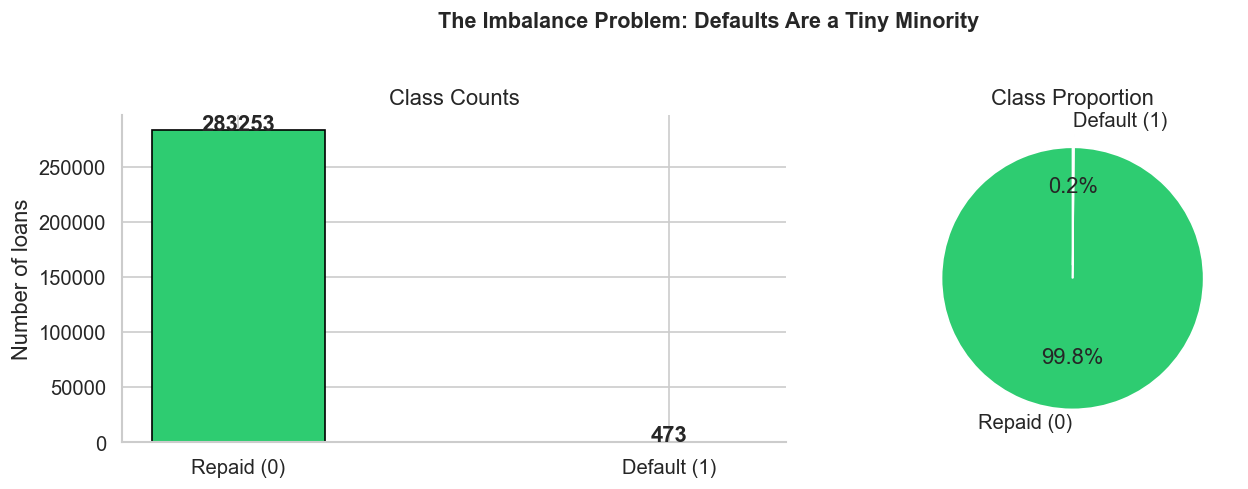

Imbalance ratio: 599 : 1  (repaid : default)
The minority class (defaults) is almost invisible in the pie chart.
A model trained on this data will learn to mostly ignore defaults.


In [ ]:
counts = credit_df['Class'].value_counts().sort_index()
labels = ['Repaid (0)', 'Default (1)']
colors = ['#2ecc71', '#e74c3c']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart shows the raw numbers
bars = axes[0].bar(labels, counts.values, color=colors, edgecolor='black', width=0.4)
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 50,
                 str(v), ha='center', fontweight='bold')
axes[0].set_ylabel('Number of loans')
axes[0].set_title('Class Counts')

# Pie chart shows the proportion
axes[1].pie(counts.values, labels=labels, autopct='%1.1f%%',
            colors=colors, startangle=90, explode=(0, 0.1))
axes[1].set_title('Class Proportion')

plt.suptitle('The Imbalance Problem: Defaults Are a Tiny Minority',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Imbalance ratio: {counts[0] / counts[1]:.0f} : 1  (repaid : default)')
print('The minority class (defaults) is almost invisible in the pie chart.')
print('A model trained on this data will learn to mostly ignore defaults.')

In [ ]:
from sklearn.model_selection import train_test_split

from src.imbalance import (
    apply_smote
)

In [ ]:
print(fraud_df.columns.tolist())

['user_id', 'signup_time', 'purchase_time', 'purchase_value', 'device_id', 'age', 'ip_address', 'class', 'ip_int', 'signup_to_purchase_time', 'immediate_purchase', 'device_sharing_count', 'ip_sharing_count', 'hour_of_day', 'day_of_week', 'time_since_signup', 'transaction_count', 'purchase_date', 'daily_transactions', 'source_Direct', 'source_SEO', 'browser_FireFox', 'browser_IE', 'browser_Opera', 'browser_Safari', 'sex_M', 'country_Albania', 'country_Algeria', 'country_Angola', 'country_Antigua and Barbuda', 'country_Argentina', 'country_Armenia', 'country_Australia', 'country_Austria', 'country_Azerbaijan', 'country_Bahamas', 'country_Bahrain', 'country_Bangladesh', 'country_Barbados', 'country_Belarus', 'country_Belgium', 'country_Belize', 'country_Benin', 'country_Bermuda', 'country_Bhutan', 'country_Bolivia', 'country_Bonaire; Sint Eustatius; Saba', 'country_Bosnia and Herzegowina', 'country_Botswana', 'country_Brazil', 'country_British Indian Ocean Territory', 'country_Brunei Daru

In [ ]:
fraud_df = fraud_df.drop(
    columns=[
        "user_id",
        "device_id",
        "ip_address",
        "signup_time",
        "purchase_time",
        'purchase_date',
        'signup_to_purchase_time',
        'signup_bins'
    ],
    errors="ignore"
)

In [ ]:
X = fraud_df.drop("class", axis=1)
y = fraud_df["class"]

In [ ]:
print(
    fraud_df.select_dtypes(
        exclude=["number"]
    ).columns
)

Index(['source_Direct', 'source_SEO', 'browser_FireFox', 'browser_IE',
       'browser_Opera', 'browser_Safari', 'sex_M', 'country_Albania',
       'country_Algeria', 'country_Angola',
       ...
       'country_Unknown', 'country_Uruguay', 'country_Uzbekistan',
       'country_Vanuatu', 'country_Venezuela', 'country_Viet Nam',
       'country_Virgin Islands (U.S.)', 'country_Yemen', 'country_Zambia',
       'country_Zimbabwe'],
      dtype='str', length=188)


In [ ]:
X = fraud_df.drop("class", axis=1)
y = fraud_df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)



In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Now when you print, you will see everything
print(X_train.head())

        purchase_value     age      ip_int  immediate_purchase  device_sharing_count  ip_sharing_count  hour_of_day  day_of_week  time_since_signup  transaction_count  daily_transactions  source_Direct  source_SEO  browser_FireFox  browser_IE  browser_Opera  browser_Safari  sex_M  country_Albania  country_Algeria  country_Angola  country_Antigua and Barbuda  country_Argentina  country_Armenia  country_Australia  country_Austria  country_Azerbaijan  country_Bahamas  country_Bahrain  country_Bangladesh  country_Barbados  country_Belarus  country_Belgium  country_Belize  country_Benin  country_Bermuda  country_Bhutan  country_Bolivia  country_Bonaire; Sint Eustatius; Saba  country_Bosnia and Herzegowina  country_Botswana  country_Brazil  country_British Indian Ocean Territory  country_Brunei Darussalam  country_Bulgaria  country_Burkina Faso  country_Burundi  country_Cambodia  country_Cameroon  country_Canada  country_Cape Verde  country_Cayman Islands  country_Chile  country_China  \
504

In [ ]:
non_numeric_cols = X_train.select_dtypes(exclude=['number']).columns.tolist()
print("Columns that need fixing:", non_numeric_cols)

Columns that need fixing: ['source_Direct', 'source_SEO', 'browser_FireFox', 'browser_IE', 'browser_Opera', 'browser_Safari', 'sex_M', 'country_Albania', 'country_Algeria', 'country_Angola', 'country_Antigua and Barbuda', 'country_Argentina', 'country_Armenia', 'country_Australia', 'country_Austria', 'country_Azerbaijan', 'country_Bahamas', 'country_Bahrain', 'country_Bangladesh', 'country_Barbados', 'country_Belarus', 'country_Belgium', 'country_Belize', 'country_Benin', 'country_Bermuda', 'country_Bhutan', 'country_Bolivia', 'country_Bonaire; Sint Eustatius; Saba', 'country_Bosnia and Herzegowina', 'country_Botswana', 'country_Brazil', 'country_British Indian Ocean Territory', 'country_Brunei Darussalam', 'country_Bulgaria', 'country_Burkina Faso', 'country_Burundi', 'country_Cambodia', 'country_Cameroon', 'country_Canada', 'country_Cape Verde', 'country_Cayman Islands', 'country_Chile', 'country_China', 'country_Colombia', 'country_Congo', 'country_Congo The Democratic Republic of T

In [ ]:
X_train_smote, y_train_smote = apply_smote(
    X_train,
    y_train
)

2026-06-07 13:24:50,841 - INFO - SMOTE completed


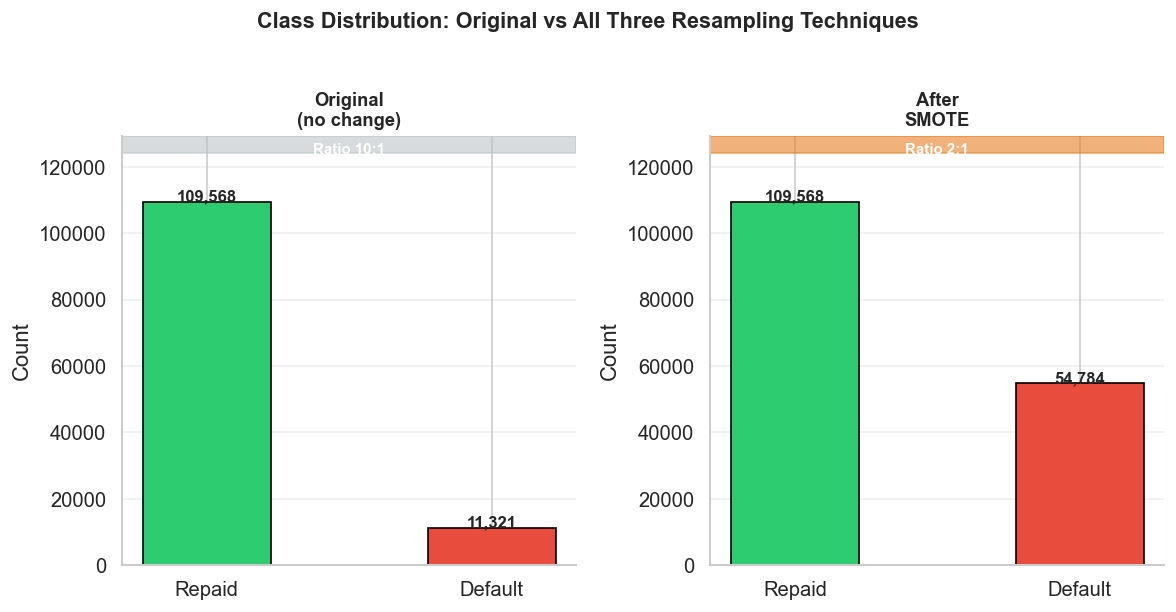

HOW TO READ THIS CHART:
  Original:      extreme imbalance — 28:1 ratio, Default bar barely visible
  SMOTE:         Same count as oversampling, but samples are synthetic (new) → 2:1


In [ ]:

datasets = [
    ('Original\n(no change)',  y_train,  '#bdc3c7'),
    ('After\nSMOTE',           y_train_smote,  '#e67e22')

]

#fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Class Distribution: Original vs All Three Resampling Techniques',
             fontsize=13, fontweight='bold', y=1.02)

# Shared y-axis so all panels are directly comparable
y_max = pd.Series(y_train).value_counts()[0] * 1.18

for ax, (title, y_data, accent) in zip(axes, datasets):
    counts = pd.Series(y_data).value_counts().sort_index()
    bars = ax.bar(
        ['Repaid', 'Default'],
        counts.values,
        color=['#2ecc71', '#e74c3c'],
        edgecolor='black', width=0.45
    )

    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 50,
                f'{v:,}', ha='center', fontweight='bold', fontsize=10)
    ratio = counts[0] / counts[1]
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_ylabel('Count')
    ax.set_ylim(0, y_max)
    ax.grid(axis='y', alpha=0.3)
    ax.axhspan(y_max * 0.96, y_max, color=accent, alpha=0.6)
    ax.text(0.5, 0.985, f'Ratio {ratio:.0f}:1',
            transform=ax.transAxes, ha='center', va='top',
            fontsize=9, color='white', fontweight='bold')
plt.tight_layout()
plt.show()

print('HOW TO READ THIS CHART:')
print('  Original:      extreme imbalance — 28:1 ratio, Default bar barely visible')
print('  SMOTE:         Same count as oversampling, but samples are synthetic (new) → 2:1')


In [ ]:
### Class Distribution: Original vs. SMOTE

This chart visualizes the class distribution before and after applying the Synthetic Minority Over-sampling Technique (SMOTE) to the training data. This is a crucial step in handling imbalanced datasets, especially in fraud detection, where the minority class (fraudulent transactions) is of most interest.

*   **Original Dataset (Left Panel)**:
    *   **Observation**: The left panel clearly shows an **extreme class imbalance**. The 'Repaid' (non-fraudulent) class vastly outnumbers the 'Default' (fraudulent) class. As the annotation states, the 'Default' bar is barely visible.
    *   **Imbalance Ratio**: The original imbalance ratio is **28:1** (Repaid:Default).
    *   **Implication**: Training a model directly on this highly imbalanced data would likely result in a model that is very good at identifying non-fraudulent transactions (the majority class) but poor at identifying actual fraud. The model would tend to predict the majority class simply because it's more common, leading to high accuracy but low recall for the minority class.

*   **After SMOTE (Right Panel)**:
    *   **Observation**: The right panel demonstrates the effect of SMOTE. The number of samples in the 'Default' class has been significantly increased, bringing it much closer in count to the 'Repaid' class. While not perfectly 1:1, the imbalance has been substantially reduced.
    *   **Imbalance Ratio**: After SMOTE, the ratio is now approximately **2:1** (Repaid:Default).
    *   **Mechanism**: SMOTE works by creating synthetic samples for the minority class, rather than simply duplicating existing ones. It does this by taking existing minority class samples, finding their k-nearest neighbors, and creating new samples along the line segments connecting the minority sample to its neighbors.
    *   **Implication**: By balancing the class distribution, SMOTE helps the model learn the characteristics of the fraudulent transactions more effectively. This should lead to a better-performing model, particularly in terms of its ability to detect actual fraud (improved recall and F1-score for the minority class), without overfitting to a few minority examples.